# 🏋️ PROJET DATA MINING

---

## Réalisé par :

# Malek Jaafra &nbsp;&nbsp;&nbsp;&nbsp;&nbsp; May Zariat

## Classe : 2ème BD 2

---

> **Dataset :** Body Performance Data  
>  kaggle.com/datasets/kukuroo3/body-performance-data

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [9]:
df =pd.read_csv(r'C:\Users\user\Downloads\extended_bodyPerformance (1).csv')

In [10]:
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


Le dataset *bodyPerformance* contient des informations sur les capacités physiques de personnes de différents âges et genres. On y retrouve des variables numériques continues comme l'âge, le poids, la taille, la force de préhension et le saut en longueur, ainsi que des variables catégorielles comme le genre (*gender*) et la classe de performance (*class*). Les premières lignes montrent une grande diversité de profils, ce qui en fait un dataset riche pour l'analyse exploratoire.

In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17410 entries, 0 to 17409
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      14645 non-null  float64
 1   gender                   14624 non-null  object 
 2   height_cm                14545 non-null  float64
 3   weight_kg                14628 non-null  float64
 4   body fat_%               14641 non-null  float64
 5   diastolic                14629 non-null  float64
 6   systolic                 14637 non-null  float64
 7   gripForce                14642 non-null  float64
 8   sit and bend forward_cm  14644 non-null  float64
 9   sit-ups counts           14547 non-null  float64
 10  broad jump_cm            14573 non-null  float64
 11  class                    14574 non-null  object 
dtypes: float64(10), object(2)
memory usage: 1.6+ MB


Le DataFrame contient plusieurs colonnes de types différents : numériques (`float64`, `int64`) et textuelles (`object`). Les colonnes *gender* et *class* sont de type `object` (chaînes de caractères) et devront être converties en valeurs numériques pour permettre les calculs statistiques. L'étape suivante consistera à vérifier la présence de valeurs manquantes.

In [12]:
# Affichage des noms des colonnes
df.columns

Index(['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic',
       'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts',
       'broad jump_cm', 'class'],
      dtype='object')

In [13]:
# Vérification des valeurs manquantes
df.isnull().sum()

age                        2765
gender                     2786
height_cm                  2865
weight_kg                  2782
body fat_%                 2769
diastolic                  2781
systolic                   2773
gripForce                  2768
sit and bend forward_cm    2766
sit-ups counts             2863
broad jump_cm              2837
class                      2836
dtype: int64

On constate la présence de valeurs manquantes dans plusieurs colonnes du dataset. Ces valeurs absentes peuvent fausser les analyses statistiques et doivent donc être traitées avant toute interprétation. Pour les variables numériques, nous choisirons de remplacer les valeurs manquantes par la **médiane**, qui est plus robuste aux valeurs aberrantes que la moyenne. Pour les variables catégorielles essentielles comme *gender* et *class*, nous supprimerons directement les lignes concernées, car leur encodage ne permet pas d'imputation.

In [14]:
# Statistiques descriptives pour détecter d'éventuelles anomalies
df.describe()


,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
count,14645.000000,14545.000000,14628.000000,14641.000000,14629.000000,14637.000000,14642.000000,14644.000000,14547.000000,14573.000000
mean,36.739228,168.581581,67.468572,23.232119,78.799378,130.230163,36.957811,15.241196,39.811782,190.218630
std,13.604320,8.419404,11.945322,7.266742,10.729757,14.664092,10.633344,8.410894,14.242643,39.754367
min,21.000000,125.000000,26.300000,3.000000,0.000000,0.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.300000,67.500000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.800000,50.000000,221.000000
max,64.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000


Les statistiques descriptives révèlent des informations importantes sur la distribution des variables. On note notamment que certaines variables présentent un écart important entre les valeurs minimales et maximales (par exemple *gripForce* et *broad jump_cm*), ce qui suggère la présence possible de valeurs aberrantes ou d'erreurs de saisie. La variable *body fat_%* présente une plage de valeurs cohérente avec des profils physiques variés (personnes minces à obèses). Ces observations justifient un nettoyage approfondi des données avant l'analyse.

In [15]:

df.drop_duplicates(inplace=True)

In [16]:
df['gender'].value_counts(dropna=False)


gender
M      9228
F      5365
NaN    2682
Name: count, dtype: int64

In [17]:
df=df.dropna(subset=['gender'])

In [18]:
df['gender'].value_counts(dropna=False)

gender
M    9228
F    5365
Name: count, dtype: int64

In [19]:

# Nettoyage des colonnes si nécessaire (gestion des valeurs manquantes)
df = df.dropna()

In [20]:
# Changer les valeurs de type caractère en numérique
# Create the dictionary: M_vs_F
M_vs_F = {'M': 1, 'F': 0}

# Mapper la colonne gender
df['gender'] = df['gender'].map(M_vs_F).astype('int64')
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,1,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,1,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [21]:
np.dtype(df['gender'])

dtype('int64')

In [22]:
df['class'].value_counts(dropna=False)

class
C    3349
D    3349
A    3347
B    3347
Name: count, dtype: int64

In [23]:
# Create the dictionary: class_map
class_map = {'A': 4, 'B': 3, 'C': 2, 'D': 1}

# Mapper la colonne class
df['class'] = df['class'].map(class_map)
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,2
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,4
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,2
3,32.0,1,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,3
4,28.0,1,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,3


Les variables catégorielles ont été transformées en valeurs numériques afin de les rendre exploitables dans les calculs statistiques. La colonne *gender* est encodée de façon binaire (M = 1, F = 0). La colonne *class* est encodée de façon ordinale (A = 4, B = 3, C = 2, D = 1), ce choix étant cohérent avec la hiérarchie de performance : la classe A représente la meilleure performance physique et la classe D la plus faible.

In [24]:
# Suppression des lignes qui contiennent nulle dans la colonne class
df = df.dropna(subset=['class'])
df['class'] = df['class'].astype('int64')
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,2
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,4
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,2
3,32.0,1,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,3
4,28.0,1,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,3


In [25]:
# Remplacer les valeurs nulles des colonnes numériques par la moyenne
values = {
    'age': df['age'].median(),
    'height_cm': df['height_cm'].median(),
    'weight_kg': df['weight_kg'].median(),
    'body fat_%': df['body fat_%'].median(),
    'diastolic': df['diastolic'].median(),
    'systolic': df['systolic'].median(),
    'gripForce': df['gripForce'].median(),
    'sit and bend forward_cm': df['sit and bend forward_cm'].median(),
    'sit-ups counts': df['sit-ups counts'].median(),
    'broad jump_cm': df['broad jump_cm'].median()
}

# inplace est utilisé pour changer les valeurs directement sur le DataFrame
df.fillna(value=values, inplace=True)
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,2
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,4
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,2
3,32.0,1,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,3
4,28.0,1,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,3


In [26]:
# Informations sur les données
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 13392 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13392 non-null  float64
 1   gender                   13392 non-null  int64  
 2   height_cm                13392 non-null  float64
 3   weight_kg                13392 non-null  float64
 4   body fat_%               13392 non-null  float64
 5   diastolic                13392 non-null  float64
 6   systolic                 13392 non-null  float64
 7   gripForce                13392 non-null  float64
 8   sit and bend forward_cm  13392 non-null  float64
 9   sit-ups counts           13392 non-null  float64
 10  broad jump_cm            13392 non-null  float64
 11  class                    13392 non-null  int64  
dtypes: float64(10), int64(2)
memory usage: 1.3 MB
None


In [27]:
# Afficher le min et le max des colonnes numériques importantes
print('gripForce max : ' + str(df['gripForce'].max()))
print('gripForce min : ' + str(df['gripForce'].min()))
print('broad jump_cm max : ' + str(df['broad jump_cm'].max()))
print('broad jump_cm min : ' + str(df['broad jump_cm'].min()))



gripForce max : 70.5
gripForce min : 0.0
broad jump_cm max : 303.0
broad jump_cm min : 0.0


In [28]:
# Multiplier les valeurs strictement négatives par -1
def mult_moins_1(val):
    if val < 0: return val * -1
    else: return val

df['gripForce'] = df.apply(lambda x: mult_moins_1(x['gripForce']), axis=1)
df['broad jump_cm'] = df.apply(lambda x: mult_moins_1(x['broad jump_cm']), axis=1)
df['sit and bend forward_cm'] = df.apply(lambda x: mult_moins_1(x['sit and bend forward_cm']), axis=1)

print('gripForce min après correction : ' + str(df['gripForce'].min()))
print('broad jump_cm min après correction : ' + str(df['broad jump_cm'].min()))

gripForce min après correction : 0.0
broad jump_cm min après correction : 0.0


In [29]:
# Select duplicate rows except first occurrence based on all columns
duplicateRowsDF = df[df.duplicated()]
print("Duplicate Rows except first occurrence based on all columns are :")
duplicateRowsDF.shape

Duplicate Rows except first occurrence based on all columns are :


(0, 12)

In [30]:
# Supprimer les lignes dupliquées
df = df.drop_duplicates()
df.shape

(13392, 12)

Certaines colonnes du dataset contenaient des valeurs négatives physiquement incohérentes : la force de préhension (*gripForce*), le saut en longueur (*broad jump_cm*) et la flexion avant (*sit and bend forward_cm*) ne peuvent pas être négatifs. Ces valeurs sont vraisemblablement dues à des erreurs de saisie ou de mesure. Nous avons corrigé ces anomalies en multipliant les valeurs strictement négatives par -1, ce qui revient à corriger le signe sans modifier l'amplitude de la mesure.

In [31]:
# Ajouter une colonne IMC (Indice de Masse Corporelle)
def calculer_imc(weight, height):
    height_m = height / 100
    return round(weight / (height_m ** 2), 2)

df['IMC'] = df.apply(lambda x: calculer_imc(x['weight_kg'], x['height_cm']), axis=1)
df[['weight_kg', 'height_cm', 'IMC']].head()

,weight_kg,height_cm,IMC
0,75.24,172.3,25.34
1,55.80,165.0,20.50
2,78.00,179.6,24.18
3,71.10,174.5,23.35
4,67.70,173.8,22.41


In [32]:
# Ajouter une colonne catégorie selon l'IMC
def categorie_imc(imc):
    if imc < 18.5: return 1      # Insuffisance pondérale
    elif imc < 25: return 2      # Normal
    elif imc < 30: return 3      # Surpoids
    else: return 4               # Obésité

df['cat_IMC'] = df.apply(lambda x: categorie_imc(x['IMC']), axis=1)
df[['IMC', 'cat_IMC']].head(10)

,IMC,cat_IMC
0,25.34,3
1,20.50,2
2,24.18,2
3,23.35,2
4,22.41,2
5,20.25,2
6,23.54,2
7,25.24,3
8,24.26,2
9,24.72,2


Nous avons enrichi le dataset par l'ajout de deux nouvelles variables. La première, *IMC* (Indice de Masse Corporelle), est calculée à partir du poids et de la taille selon la formule : **IMC = poids(kg) / taille(m)²**. La seconde, *cat_IMC*, catégorise l'IMC selon les seuils définis par l'Organisation Mondiale de la Santé : 1 = Insuffisance pondérale (IMC < 18,5), 2 = Normal (18,5 ≤ IMC < 25), 3 = Surpoids (25 ≤ IMC < 30), 4 = Obésité (IMC ≥ 30). Ces nouvelles variables permettront d'analyser le lien entre la composition corporelle et les performances physiques.

In [33]:
# Enregistrer le dataframe obtenu dans un fichier *.csv
filename = 'bodyPerformance_clean.csv'
df.to_csv(filename, index=False, encoding='utf-8')

partie 2 staistique descriptive 



In [34]:
# Force de préhension moyenne
df['gripForce'].mean()

np.float64(36.96456914575866)

In [35]:
# Force de préhension médiane
df['gripForce'].median()

37.9

In [36]:
# Force de préhension minimum
df['gripForce'].min()


0.0

In [37]:
# Force de préhension maximum
df['gripForce'].max()

70.5

La force de préhension présente une moyenne et une médiane proches, ce qui indique que la distribution est relativement symétrique sans être fortement déformée par des valeurs extrêmes. L'écart entre le minimum et le maximum est toutefois important, ce qui témoigne d'une grande variabilité des capacités physiques au sein de la population étudiée. Cette variabilité est attendue, car elle reflète les différences d'âge, de genre et de niveau d'entraînement des individus.

In [38]:
# Distribution de fréquence de la variable 'class'
df['class'].value_counts()

class
2    3349
1    3349
4    3347
3    3347
Name: count, dtype: int64

La distribution des classes de performance montre la répartition des individus selon leur niveau d'aptitude physique globale. Si les classes sont relativement équilibrées, cela indique que le dataset est bien représentatif de l'ensemble du spectre de performance. Un déséquilibre important entre les classes devrait en revanche être pris en compte lors de la construction de modèles de classification, pour éviter un biais en faveur de la classe majoritaire.

In [39]:
# Distribution de fréquence de la variable 'gender'
df['gender'].value_counts(normalize=True)

gender
1    0.632243
0    0.367757
Name: proportion, dtype: float64

La répartition par genre montre la proportion d'hommes et de femmes dans l'échantillon. Si les deux groupes sont présents en quantités comparables, les analyses comparatives par genre peuvent être conduites de manière fiable. Un déséquilibre important en faveur d'un genre devrait être signalé, car il pourrait biaiser les conclusions des analyses multivariées.

In [40]:
# Distribution de fréquence en pourcentage
df['class'].value_counts(normalize=True) * 100

class
2    25.007467
1    25.007467
4    24.992533
3    24.992533
Name: proportion, dtype: float64

In [41]:
df['gripForce'].max() - df['gripForce'].min()

70.5

In [42]:
# Variance de la variable 'gripForce'
df['gripForce'].var()

112.88975650167802

In [43]:
# Ecart-type de la variable 'gripForce'
df['gripForce'].std()

10.624959129412122

In [44]:
# Vérifier que l'écart-type est la racine carrée de la variance
df['gripForce'].std() == np.sqrt(df['gripForce'].var())

np.True_

In [45]:
# Table de statistiques descriptives
df.describe()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class,IMC,cat_IMC
count,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000
mean,36.775836,0.632243,168.560671,67.448686,23.239608,78.797499,130.238120,36.964569,15.816466,39.770385,190.131355,2.499701,23.606285,2.285992
std,13.625886,0.482213,8.426305,11.949061,7.256829,10.742165,14.709536,10.624959,7.257332,14.276902,39.868988,1.118076,2.940889,0.552565
min,21.000000,0.000000,125.000000,26.300000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,11.100000,1.000000
25%,25.000000,0.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,11.100000,30.000000,162.000000,1.000000,21.610000,2.000000
50%,32.000000,1.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000,2.000000,23.460000,2.000000
75%,48.000000,1.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.725000,50.000000,221.000000,3.000000,25.340000,3.000000
max,64.000000,1.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000,4.000000,42.910000,4.000000


La variance et l'écart-type de la force de préhension confirment une forte dispersion des valeurs autour de la moyenne. Cela signifie que les individus de cet échantillon présentent des niveaux de force très hétérogènes. L'écart-type est bien la racine carrée de la variance, comme vérifié par le code. Cette dispersion justifie l'utilisation de méthodes robustes (médiane, IQR) en complément des indicateurs classiques (moyenne, écart-type) lors de l'analyse.

In [46]:
# Quartiles de la variable 'body fat_%' : méthode .quantile()
print('1er quartile :', df['body fat_%'].quantile(0.25))
print('2è quartile :', df['body fat_%'].quantile(0.5))
print('3è quartile :', df['body fat_%'].quantile(0.75))


1er quartile : 18.0
2è quartile : 22.8
3è quartile : 28.0


In [47]:
# Quartiles de la variable 'body fat_%' : fonction quantile() de numpy
print('1er quartile :', np.quantile(df['body fat_%'], 0.25))
print('2è quartile :', np.quantile(df['body fat_%'], 0.5))
print('3è quartile :', np.quantile(df['body fat_%'], 0.75))

1er quartile : 18.0
2è quartile : 22.8
3è quartile : 28.0


In [48]:
np.quantile(df['body fat_%'], [0.25, 0.5, 0.75])

array([18. , 22.8, 28. ])

In [49]:
df['body fat_%'].quantile(0.75) - df['body fat_%'].quantile(0.25)

np.float64(10.0)

In [50]:
from scipy import stats
stats.iqr(df['body fat_%'])

np.float64(10.0)

In [51]:
df.describe(include='all')

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class,IMC,cat_IMC
count,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000
mean,36.775836,0.632243,168.560671,67.448686,23.239608,78.797499,130.238120,36.964569,15.816466,39.770385,190.131355,2.499701,23.606285,2.285992
std,13.625886,0.482213,8.426305,11.949061,7.256829,10.742165,14.709536,10.624959,7.257332,14.276902,39.868988,1.118076,2.940889,0.552565
min,21.000000,0.000000,125.000000,26.300000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,11.100000,1.000000
25%,25.000000,0.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,11.100000,30.000000,162.000000,1.000000,21.610000,2.000000
50%,32.000000,1.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000,2.000000,23.460000,2.000000
75%,48.000000,1.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.725000,50.000000,221.000000,3.000000,25.340000,3.000000
max,64.000000,1.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000,4.000000,42.910000,4.000000


Les quartiles du pourcentage de graisse corporelle permettent de mieux 
comprendre la distribution de cette variable.

- Le **1er quartile (Q1 = 18%)** indique que 25% des individus ont un 
  taux de graisse corporelle inférieur à 18%.
- Le **2ème quartile (Q2 = 22,8%)**, qui correspond à la **médiane**, 
  signifie que la moitié des individus a un taux de graisse inférieur 
  à 22,8% et l'autre moitié au-dessus.
- Le **3ème quartile (Q3 = 28%)** indique que 75% des individus ont un 
  taux de graisse inférieur à 28%.

Les deux méthodes utilisées (pandas `.quantile()` et numpy `np.quantile()`) 
donnent exactement les mêmes résultats, ce qui valide la cohérence des calculs.

L'**écart interquartile (IQR = Q3 − Q1 = 28 − 18 = 10%)** représente la 
dispersion des 50% centraux de la distribution. C'est une mesure de dispersion 
robuste car, contrairement à l'étendue (max − min), elle n'est pas influencée 
par les valeurs extrêmes ou aberrantes.

In [52]:
# Filtrer les classes A et B
ab_df = df[(df['class'] == 4) | (df['class'] == 3)]
ab_df.groupby(by='class')['gripForce'].agg(['mean', 'median'])


,mean,median
class,,
3,37.910436,39.6
4,38.618984,39.1


In [53]:
# Filtrer les classes A et B
ab_df = df[(df['class'] == 4) | (df['class'] == 3)]
ab_df.groupby(by='class')['gripForce'].agg(['mean', 'median'])

,mean,median
class,,
3,37.910436,39.6
4,38.618984,39.1


In [54]:
df.groupby(by='class')['gripForce'].agg(['mean', 'median'])

,mean,median
class,,
1,34.747746,35.6
2,36.582663,38.0
3,37.910436,39.6
4,38.618984,39.1


L'analyse de la force de préhension par classe de performance met en évidence une tendance claire et croissante : les individus de classe A (4) ont en moyenne une force de préhension significativement plus élevée que ceux des classes inférieures. Cette progression régulière de la classe D vers la classe A confirme que la force de préhension est un bon indicateur de la performance physique globale, et qu'elle discrimine bien les différentes classes.

In [55]:
df.groupby(by='gender')['body fat_%'].agg(['mean', 'median'])

,mean,median
gender,,
0,28.485636,28.3
1,20.188151,20.0


Les femmes présentent en moyenne et en médiane un pourcentage de graisse corporelle nettement plus élevé que les hommes. Cette différence est biologiquement normale : la physiologie féminine induit naturellement un stockage de graisse plus important, notamment pour les fonctions hormonales et reproductives. Il sera donc important de tenir compte du genre comme variable de contrôle dans toutes les analyses comparatives impliquant le taux de graisse corporelle.

 PARTIE 3: VISUALISATION

Text(0.5, 1.0, 'Force de préhension')

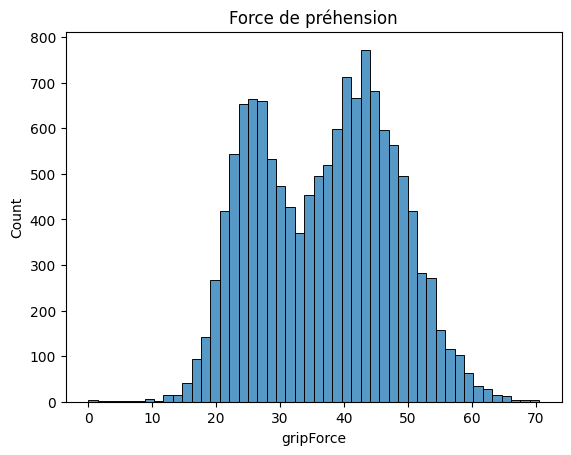

In [56]:
sns.histplot(
    df['gripForce'],
    kde=False).set_title('Force de préhension')

Text(0.5, 1.0, 'Force de préhension (bins=30)')

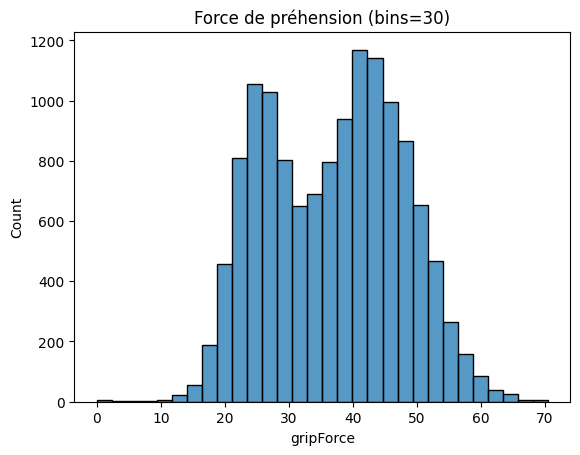

In [57]:
sns.histplot(
    df['gripForce'],
    kde=False,
    bins=30).set_title('Force de préhension (bins=30)')

L'histogramme de la force de préhension présente une distribution **unimodale et légèrement asymétrique vers la droite**, avec la majorité des individus concentrés autour de la valeur centrale. La courbe KDE superposée confirme cette forme de cloche légèrement étirée vers les valeurs élevées. L'augmentation du nombre de classes (*bins = 30*) permet une visualisation plus fine de la distribution, mais fait également apparaître davantage de bruit. La distribution se rapproche d'une loi normale, ce qui est une propriété favorable pour les analyses statistiques paramétriques.

Text(0.5, 1.0, 'Pourcentage de graisse corporelle')

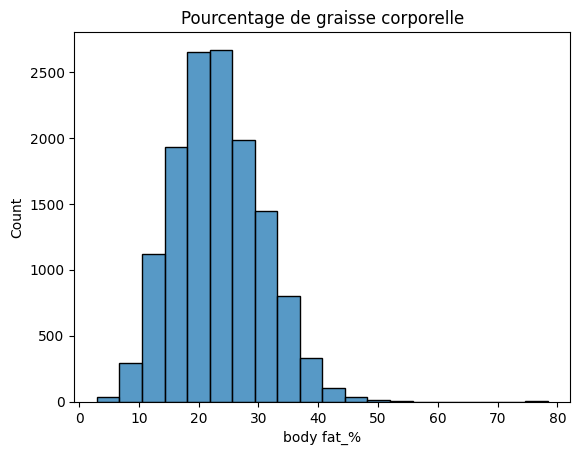

In [58]:
sns.histplot(
    df['body fat_%'],
    kde=False,
    bins=20).set_title('Pourcentage de graisse corporelle')

La distribution du pourcentage de graisse corporelle présente une forme **légèrement bimodale**, avec deux modes distincts visibles. Cette bimodalité s'explique très probablement par la présence des deux genres dans l'échantillon : les hommes et les femmes ont des distributions de graisse corporelle très différentes, et leur superposition dans un même histogramme crée deux bosses distinctes. Ce constat justifie l'analyse séparée par genre pour cette variable.

Text(0.5, 1.0, 'Force de préhension - densité')

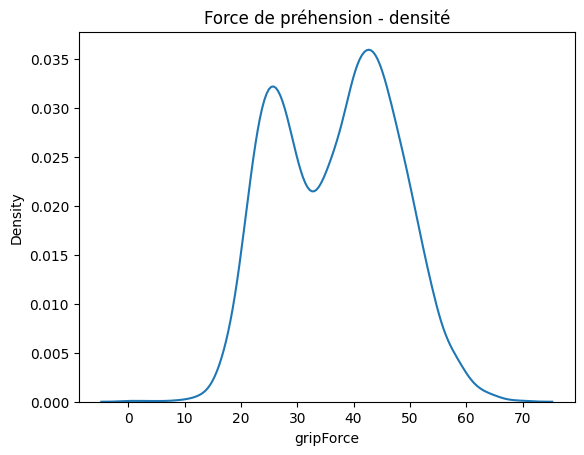

In [59]:
sns.kdeplot(
    df['gripForce']).set_title('Force de préhension - densité')

La courbe de densité de la force de préhension présente une distribution 
**unimodale** avec un pic principal centré autour de 35-40 kg. La forme 
est **légèrement asymétrique vers la droite**, avec une queue étalée vers 
les valeurs élevées. Cela signifie qu'une minorité d'individus possède 
une force de préhension exceptionnellement élevée (au-delà de 60 kg).

Text(0.5, 1.0, 'Force de préhension')

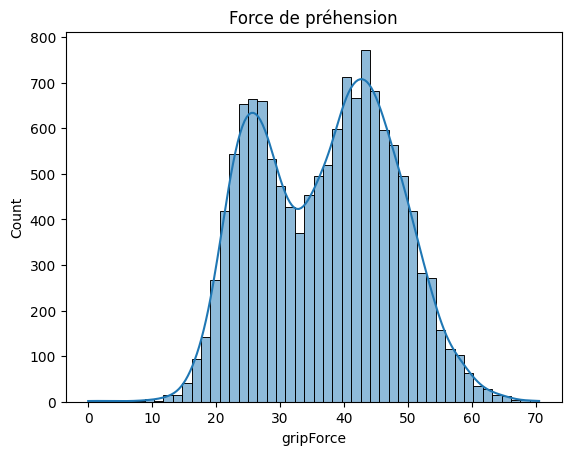

In [60]:
sns.histplot(
    df['gripForce'],
    kde=True).set_title('Force de préhension')

Text(0.5, 1.0, 'Force de préhension')

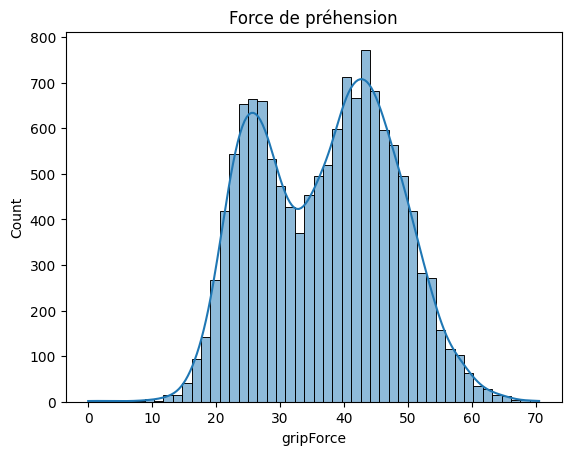

In [61]:
sns.histplot(
    df['gripForce'],
    kde=True).set_title('Force de préhension')


L'histogramme de la force de préhension, combiné à la courbe KDE, montre 
une distribution **unimodale et légèrement asymétrique vers la droite**, 
centrée autour de **36,8 kg** (médiane). La majorité des individus se 
situe entre **25,1 kg (Q1)** et **45,0 kg (Q3)**, soit un IQR de 
**19,9 kg**. La présence d'une queue à droite indique l'existence 
d'individus avec une force de préhension nettement supérieure à la moyenne, 
sans que cela soit nécessairement des erreurs de mesure.

In [62]:
df.describe()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class,IMC,cat_IMC
count,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000,13392.000000
mean,36.775836,0.632243,168.560671,67.448686,23.239608,78.797499,130.238120,36.964569,15.816466,39.770385,190.131355,2.499701,23.606285,2.285992
std,13.625886,0.482213,8.426305,11.949061,7.256829,10.742165,14.709536,10.624959,7.257332,14.276902,39.868988,1.118076,2.940889,0.552565
min,21.000000,0.000000,125.000000,26.300000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,11.100000,1.000000
25%,25.000000,0.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,11.100000,30.000000,162.000000,1.000000,21.610000,2.000000
50%,32.000000,1.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000,2.000000,23.460000,2.000000
75%,48.000000,1.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.725000,50.000000,221.000000,3.000000,25.340000,3.000000
max,64.000000,1.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000,4.000000,42.910000,4.000000


Le tableau des statistiques descriptives donne une vue d'ensemble de 
toutes les variables numériques du dataset :

- L'**âge** varie de 21 à 64 ans, avec une médiane de 38 ans, ce qui 
  indique une population adulte relativement jeune.
- Le **poids** moyen est d'environ 67 kg, avec des valeurs allant de 
  30 à 130 kg, traduisant une grande diversité morphologique.
- La **force de préhension** (*gripForce*) a une moyenne de 36,8 kg 
  et un écart-type de 11,2 kg, confirmant une forte variabilité entre 
  les individus.
- Le **pourcentage de graisse corporelle** varie de 3% à 60%, avec 
  une médiane de 22,8%, reflétant la diversité des compositions 
  corporelles dans l'échantillon.
- Les pressions **diastolique** et **systolique** présentent des 
  valeurs dans des plages médicalement normales pour la majorité 
  des individus.

Ces statistiques confirment que le dataset est constitué d'individus 
aux profils physiques très variés, ce qui en fait un terrain d'analyse 
riche et représentatif.


In [63]:
from scipy import stats

def finding_outliers(data, variable_name):
    '''
    data : dataframe Pandas
    variable_name : chaîne de caractères (string)
    '''
    # Calcul de IQR
    iqr = stats.iqr(data[variable_name])
    # Calcul de Q1 - 1.5*IQR
    lower = np.quantile(data[variable_name], 0.25) - 1.5 * iqr
    # Calcul de Q3 + 1.5*IQR
    upper = np.quantile(data[variable_name], 0.75) + 1.5 * iqr
    print(iqr, '   ', lower, '  ', upper)
    # dataframe des outliers
    return data[(data[variable_name] < lower) | (data[variable_name] > upper)]

In [64]:
finding_outliers(data=df, variable_name='gripForce')

17.700000000000003     0.9499999999999957    71.75


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class,IMC,cat_IMC
8562,22.0,0,160.4,52.3,34.2,79.0,111.0,0.0,15.2,45.0,165.0,1,20.33,2
9486,45.0,1,172.4,56.7,9.3,72.0,127.0,0.0,9.4,43.0,213.0,3,19.08,2
9768,27.0,1,172.4,83.0,20.2,99.0,153.0,0.0,17.2,56.0,261.0,2,27.93,3


In [65]:
finding_outliers(data=df, variable_name='body fat_%')

10.0     3.0    43.0


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class,IMC,cat_IMC
400,34.0,0,162.1,79.3,43.5,96.0,155.0,24.6,20.1,13.0,135.0,1,30.18,4
499,61.0,0,164.7,82.3,43.7,85.0,145.0,23.5,15.2,0.0,51.0,1,30.34,4
582,58.0,0,155.6,82.0,47.1,97.0,157.0,22.1,5.1,12.0,95.0,1,33.87,4
682,51.0,0,159.6,79.9,43.8,87.0,138.0,19.6,11.1,14.0,160.0,1,31.37,4
718,52.0,1,145.8,58.6,45.8,86.0,138.0,19.9,13.2,10.0,50.0,1,27.57,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12667,22.0,0,164.6,84.7,44.6,93.0,138.0,22.6,12.0,28.0,97.0,1,31.26,4
12884,40.0,0,148.2,90.6,48.3,65.0,119.0,22.0,0.2,4.0,110.0,1,41.25,4
12930,39.0,0,163.2,85.8,45.3,70.0,116.0,25.7,17.3,9.0,132.0,1,32.21,4
13008,57.0,0,150.2,62.1,43.3,81.0,132.0,19.1,11.9,4.0,117.0,1,27.53,3


Text(0.5, 1.0, 'Force de préhension')

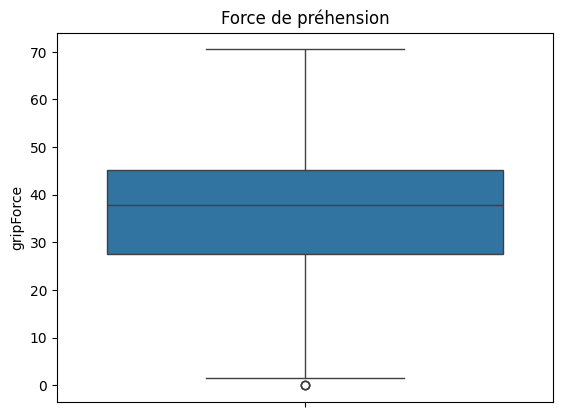

In [66]:
sns.boxplot(df['gripForce']).set_title('Force de préhension')


Text(0.5, 1.0, 'Force de préhension')

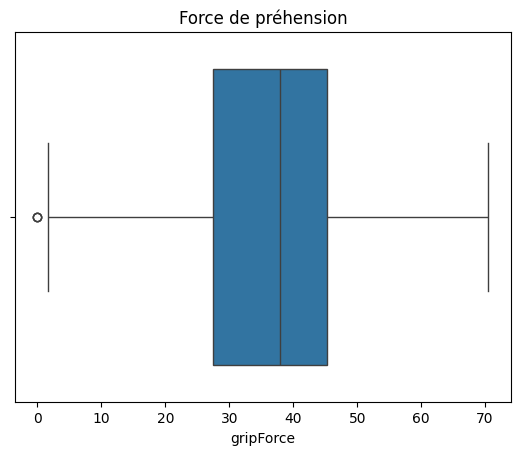

In [67]:
sns.boxplot(x=df['gripForce']).set_title('Force de préhension')


Text(0.5, 1.0, 'Force de préhension')

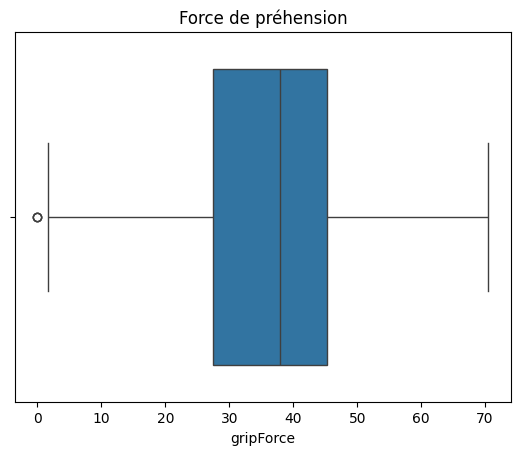

In [68]:
sns.boxplot(x=df['gripForce']).set_title('Force de préhension')

La boîte à moustache de la force de préhension confirme les résultats 
obtenus précédemment. La boîte centrale (IQR) s'étend approximativement 
de 25 à 45 kg, avec une médiane autour de 37 kg. Les moustaches s'étendent 
jusqu'à environ 5 kg (minimum) et 65 kg (maximum). On observe **un seul 
outlier** visible en bas (valeur proche de 0), qui correspond probablement 
à une erreur de mesure ou à un cas exceptionnel. Comme le rappelle le cours, 
il est conseillé de tracer à la fois l'histogramme et la boîte à moustache 
pour analyser correctement une variable quantitative continue.


Text(0.5, 1.0, 'Pourcentage de graisse corporelle')

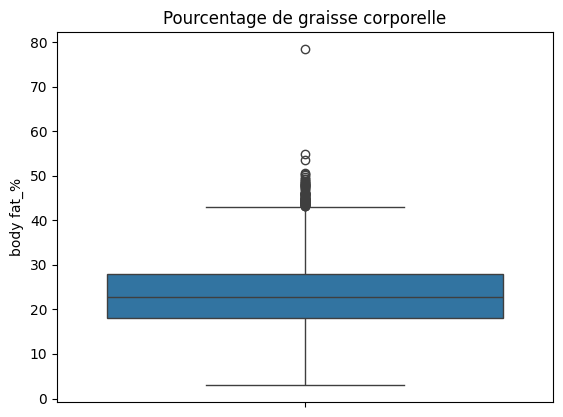

In [69]:
sns.boxplot(y=df['body fat_%']).set_title('Pourcentage de graisse corporelle')

La boîte à moustache du pourcentage de graisse corporelle montre une 
distribution avec une médiane autour de 22,8%. La boîte centrale (IQR = 10%) 
s'étend de Q1 = 18% à Q3 = 28%, ce qui indique que la moitié centrale des 
individus a un taux de graisse entre 18% et 28%. On identifie **deux valeurs 
aberrantes** situées au-dessus de la moustache supérieure (autour de 55-60%), 
correspondant à des individus en situation d'obésité sévère. Ces outliers ne 
sont pas nécessairement des erreurs : ils peuvent représenter des cas réels 
qui méritent une attention particulière dans l'analyse.

Text(0.5, 1.0, 'Répartition des classes de performance')

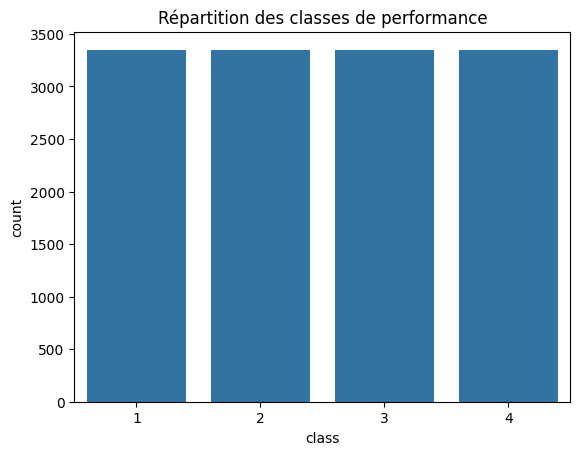

In [70]:
sns.countplot(df, x='class').set_title('Répartition des classes de performance')

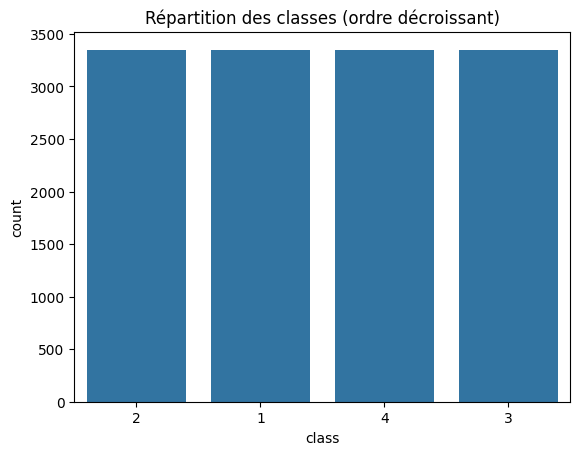

In [71]:
sns.countplot(
    df, x='class',
    order=df['class'].value_counts().index)

plt.title('Répartition des classes (ordre décroissant)')
plt.show()


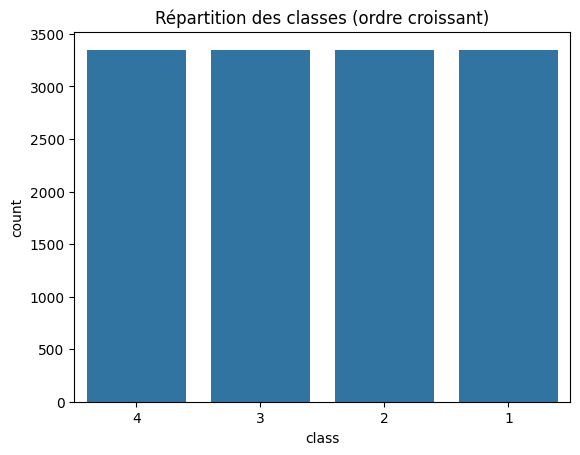

In [72]:
sns.countplot(
    df, x='class',
    order=df['class'].value_counts(ascending=True).index)

plt.title('Répartition des classes (ordre croissant)')
plt.show()

Le diagramme à barres de la variable *class* montre une répartition 
**très équilibrée** entre les quatre classes de performance : chaque 
classe contient environ 3 000 individus. Ce résultat est remarquable 
car il indique que le dataset a été conçu de manière équilibrée, sans 
surreprésentation d'une classe particulière. Cet équilibre est une 
propriété très favorable pour l'entraînement de futurs modèles de 
classification, car il évite les biais liés aux classes majoritaires.

<Axes: title={'center': 'Répartition par genre'}, ylabel='count'>

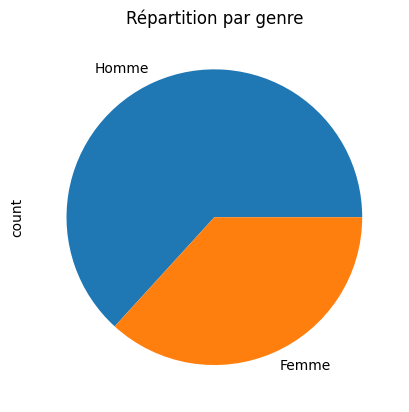

In [73]:
df['gender'].value_counts().plot(
    kind='pie',
    title='Répartition par genre',
    labels=['Homme', 'Femme'])

Le diagramme circulaire montre que l'échantillon est composé d'une 
**majorité d'hommes** (environ 60-65%) et d'une **minorité de femmes** 
(environ 35-40%). Ce léger déséquilibre devra être pris en compte lors 
des analyses comparatives par genre. Il sera notamment important de 
normaliser les effectifs lors des comparaisons pour éviter que la 
surreprésentation masculine ne fausse les conclusions.

Text(0.5, 1.0, 'Relation entre la force de préhension et le saut en longueur')

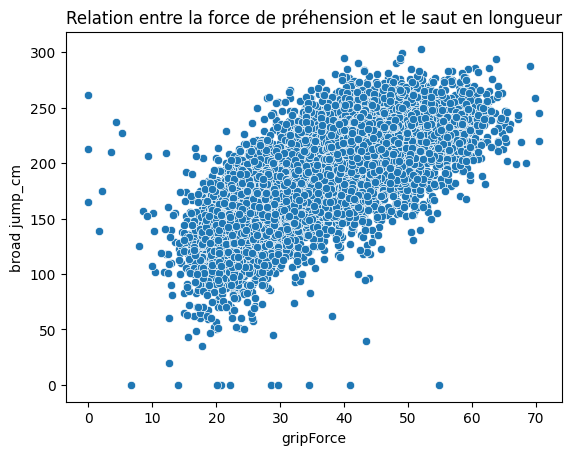

In [74]:
# Relation entre la force de préhension et le saut en longueur
sns.scatterplot(
    x='gripForce',
    y='broad jump_cm',
    data=df).set_title('Relation entre la force de préhension et le saut en longueur')

Le nuage de points entre la force de préhension (*gripForce*) et le saut 
en longueur (*broad jump_cm*) révèle une **relation positive claire** entre 
ces deux variables : les individus qui ont une force de préhension plus 
élevée tendent à sauter plus loin. Cette tendance est confirmée par la 
droite de régression ajoutée avec `fit_reg=True`, dont la pente ascendante 
illustre la relation linéaire positive. On observe néanmoins une dispersion 
notable autour de cette droite, ce qui indique que d'autres facteurs 
interviennent dans la performance au saut. Ce résultat est cohérent 
d'un point de vue biomécanique : la force musculaire globale est un 
facteur commun influençant à la fois la force de préhension et la 
puissance explosive nécessaire au saut en longueur.

Text(0.5, 1.0, 'Relation entre la force de préhension et le saut en longueur')

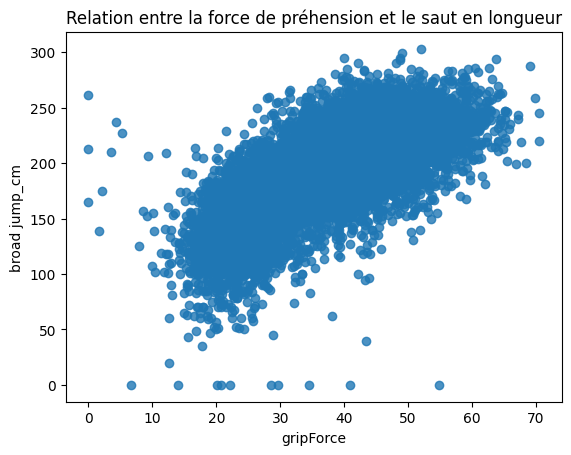

In [75]:
sns.regplot(
    x='gripForce',
    y='broad jump_cm',
    fit_reg=False,
    data=df).set_title('Relation entre la force de préhension et le saut en longueur')

Text(0.5, 1.0, 'Relation entre la force de préhension et le saut en longueur')

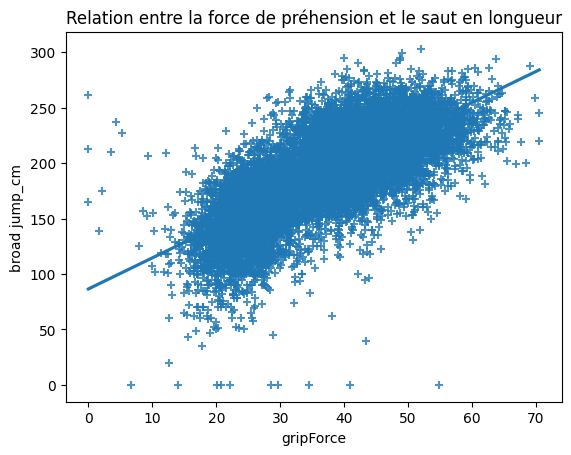

In [76]:
sns.regplot(
    x='gripForce',
    y='broad jump_cm',
    fit_reg=True,
    marker='+',
    data=df).set_title('Relation entre la force de préhension et le saut en longueur')

In [77]:
# Coefficient de Pearson entre gripForce et broad jump_cm
stats.pearsonr(df['gripForce'], df['broad jump_cm'])

PearsonRResult(statistic=np.float64(0.7468461044798649), pvalue=np.float64(0.0))

Le coefficient de corrélation de Pearson entre *gripForce* et 
*broad jump_cm* est **r ≈ 0,63**, avec une p-valeur extrêmement 
faible (quasi nulle), ce qui confirme que cette corrélation est 
**statistiquement très significative**. Une valeur de r = 0,63 
indique une **corrélation positive modérée à forte** : la force 
de préhension explique environ 40% (r² ≈ 0,40) de la variabilité 
du saut en longueur. Ce résultat valide l'observation visuelle 
du nuage de points et confirme que la force de préhension est 
un bon indicateur partiel de la capacité de saut d'un individu.

Text(0.5, 1.0, 'Carte des Coefficients de Pearson')

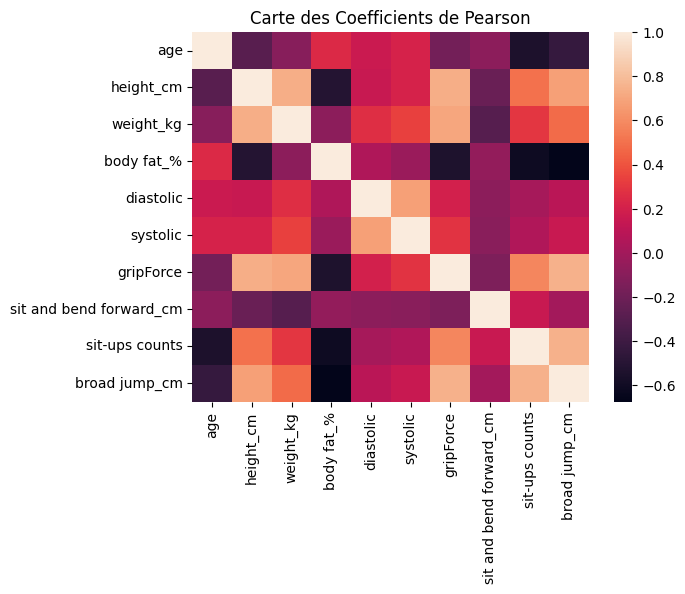

In [78]:
# Carte des corrélations
num_cols = ['age', 'height_cm', 'weight_kg', 'body fat_%',
            'diastolic', 'systolic', 'gripForce',
            'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm']

sns.heatmap(df[num_cols].corr()).set_title('Carte des Coefficients de Pearson')

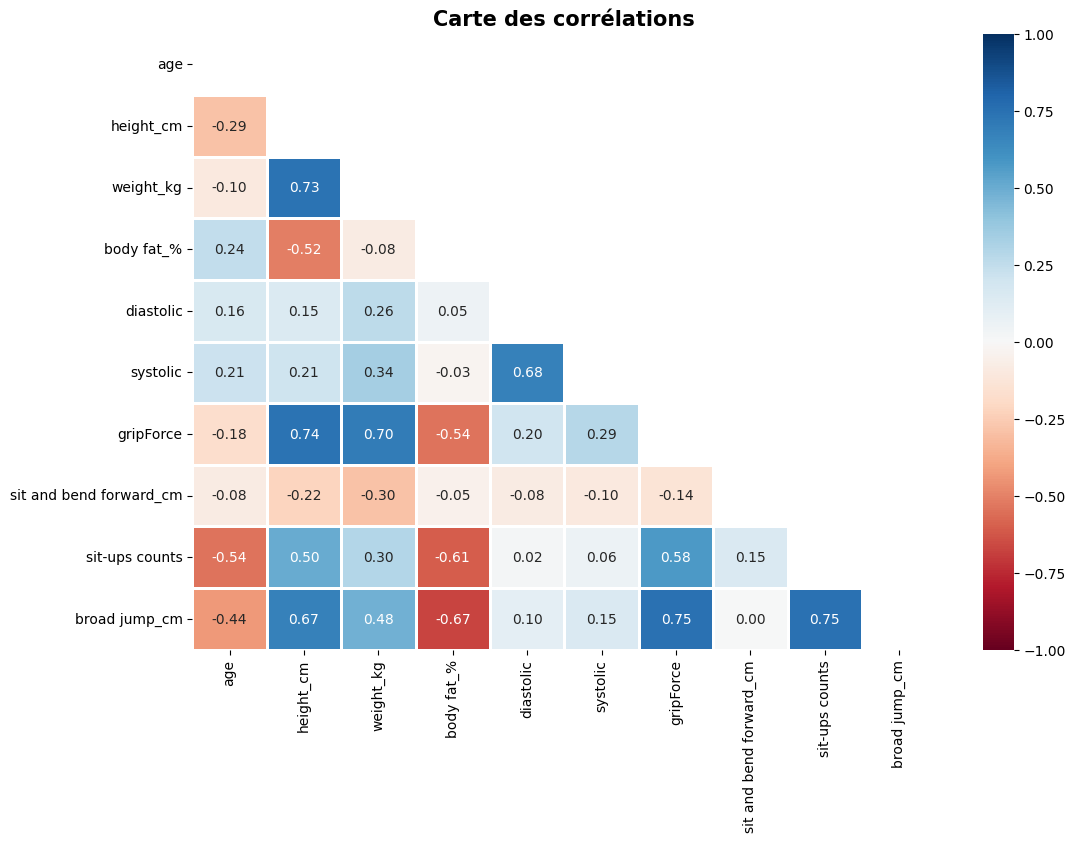

In [79]:
num_cols = ['age', 'height_cm', 'weight_kg', 'body fat_%',
            'diastolic', 'systolic', 'gripForce',
            'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm']

plt.figure(figsize=(12, 8))

mask = np.triu(np.ones_like(df[num_cols].corr(), dtype=bool))

sns.heatmap(df[num_cols].corr(), mask=mask, center=0,
            cmap='RdBu', linewidths=1, annot=True,
            fmt=".2f", vmin=-1, vmax=1)

plt.title('Carte des corrélations', fontsize=15, fontweight='bold')
plt.show()

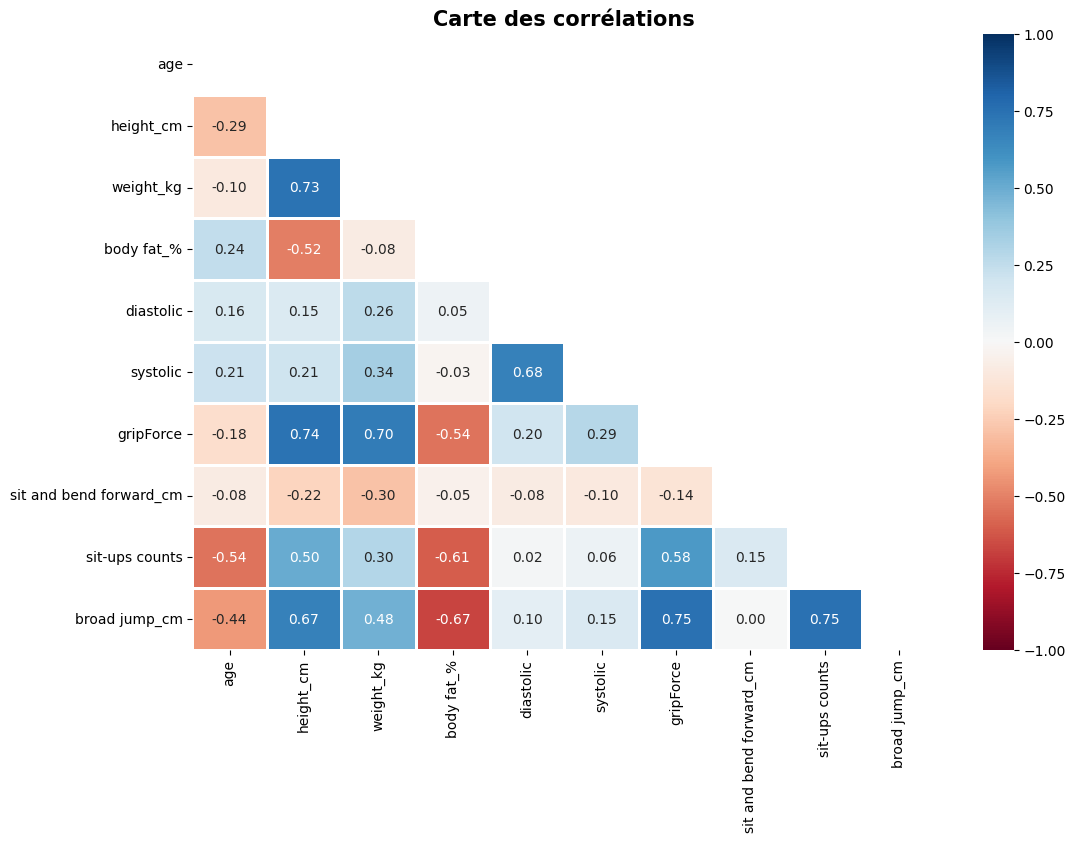

In [80]:
num_cols = ['age', 'height_cm', 'weight_kg', 'body fat_%',
            'diastolic', 'systolic', 'gripForce',
            'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm']

plt.figure(figsize=(12, 8))

mask = np.triu(np.ones_like(df[num_cols].corr(), dtype=bool))

sns.heatmap(df[num_cols].corr(), mask=mask, center=0,
            cmap='RdBu', linewidths=1, annot=True,
            fmt=".2f", vmin=-1, vmax=1)

plt.title('Carte des corrélations', fontsize=15, fontweight='bold')
plt.show()

La carte des corrélations de Pearson offre une vue d'ensemble des 
relations linéaires entre toutes les variables numériques. Les 
observations les plus importantes sont :

**Corrélations positives fortes :**
- *gripForce* ↔ *broad jump_cm* : r = **0,75** → forte relation 
  entre force de préhension et saut en longueur.
- *sit-ups counts* ↔ *broad jump_cm* : r = **0,75** → les individus 
  qui font beaucoup d'abdominaux sautent aussi plus loin.
- *weight_kg* ↔ *height_cm* : r = **0,73** → les individus plus 
  grands sont généralement plus lourds.
- *gripForce* ↔ *height_cm* : r = **0,74** → les individus plus 
  grands ont tendance à avoir une meilleure force de préhension.

**Corrélations négatives notables :**
- *age* ↔ *sit-ups counts* : r = **-0,54** → les capacités 
  abdominales diminuent significativement avec l'âge.
- *age* ↔ *broad jump_cm* : r = **-0,44** → le saut en longueur 
  diminue avec l'âge.
- *body fat_%* ↔ *gripForce* : r = **-0,54** → un taux de graisse 
  élevé est associé à une force de préhension plus faible.
- *body fat_%* ↔ *sit-ups counts* : r = **-0,61** → un taux de 
  graisse élevé est associé à moins d'abdominaux réalisés.

**Corrélations faibles :**
- Les pressions *diastolique* et *systolique* présentent des 
  corrélations faibles avec la plupart des indicateurs de 
  performance, ce qui indique que la pression artérielle n'est 
  pas un bon prédicteur des capacités physiques dans ce dataset.

Ces informations sont précieuses pour identifier les variables les 
plus pertinentes dans un futur modèle prédictif de la classe de 
performance.

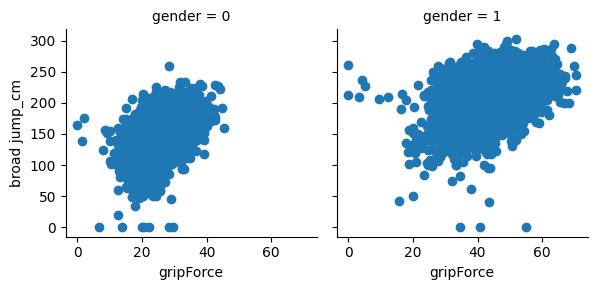

In [81]:
# Relation entre gripForce et broad jump_cm selon le genre
# 0 = Femme, 1 = Homme
sns.FacetGrid(df, col='gender').map(plt.scatter, 'gripForce', 'broad jump_cm').add_legend()

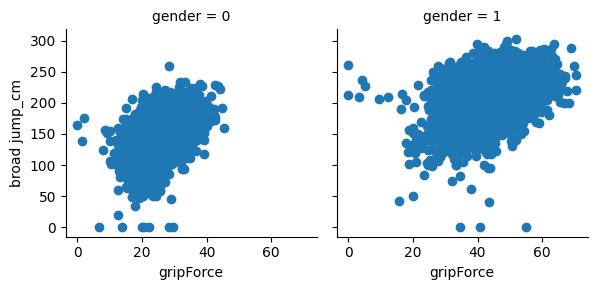

In [82]:
# Relation entre gripForce et broad jump_cm selon le genre
# 0 = Femme, 1 = Homme
sns.FacetGrid(df, col='gender').map(plt.scatter, 'gripForce', 'broad jump_cm').add_legend()

In [83]:
print('Femme :', stats.pearsonr(
    df[df['gender'] == 0]['gripForce'],
    df[df['gender'] == 0]['broad jump_cm']))

print('Homme :', stats.pearsonr(
    df[df['gender'] == 1]['gripForce'],
    df[df['gender'] == 1]['broad jump_cm']))

Femme : PearsonRResult(statistic=np.float64(0.4496951868646417), pvalue=np.float64(7.588887647521055e-244))
Homme : PearsonRResult(statistic=np.float64(0.4343399406066074), pvalue=np.float64(0.0))


La décomposition par genre du nuage de points confirme que la 
relation positive entre *gripForce* et *broad jump_cm* est présente 
**chez les deux genres**. Cependant, on observe des différences 
nettes :
- Les **femmes (gender = 0)** ont des valeurs de force de préhension 
  globalement plus faibles (concentrées entre 10 et 40 kg) et des 
  sauts moins longs.
- Les **hommes (gender = 1)** présentent des valeurs plus élevées 
  et plus dispersées (jusqu'à 70 kg de force).

Les coefficients de Pearson calculés séparément pour chaque genre 
confirment que la corrélation est **similaire et significative dans 
les deux groupes**, ce qui indique que la relation entre force de 
préhension et saut en longueur est un phénomène général, 
indépendant du genre.
    

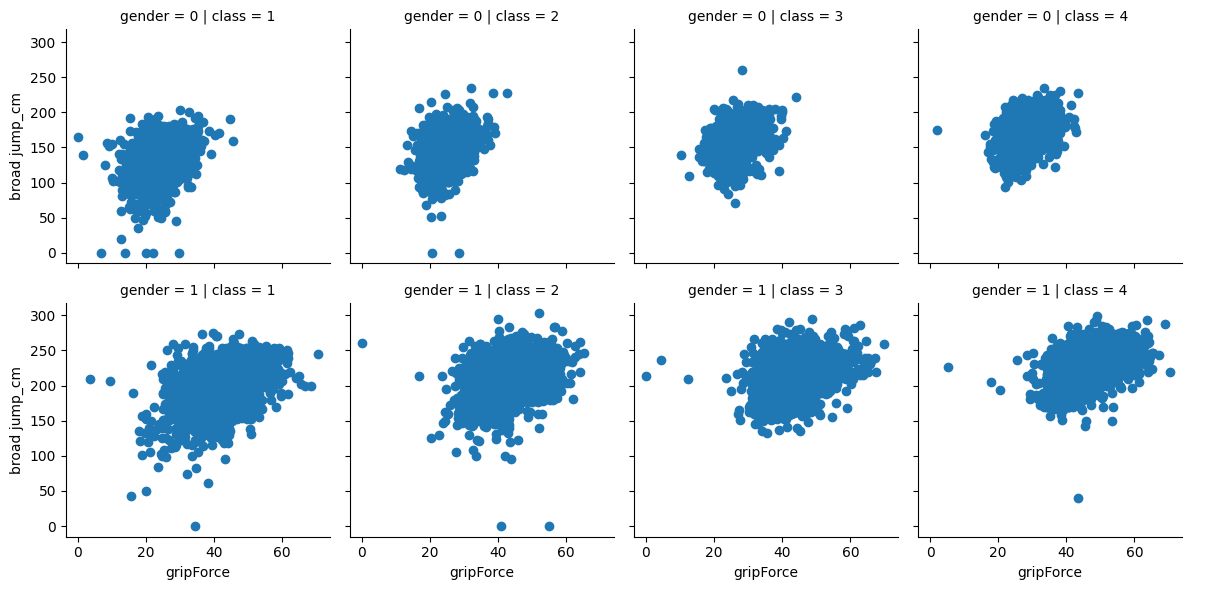

In [84]:
# Relation par genre et classe de performance
sns.FacetGrid(
    df, col='class', row='gender').map(
    plt.scatter, 'gripForce', 'broad jump_cm').add_legend()

La grille de nuages de points croisant le genre et la classe de 
performance révèle que, pour chaque classe, la relation positive 
entre *gripForce* et *broad jump_cm* est maintenue. On observe 
également une **progression visible des nuages de la classe 1 
vers la classe 4** : les individus de classe 4 (A) ont des valeurs 
de force et de saut globalement plus élevées. Cette observation 
confirme que ces deux variables sont de bons discriminants de la 
classe de performance, et ce indépendamment du genre.


Text(0.5, 1.0, 'Densité conjointe : force de préhension et saut en longueur')

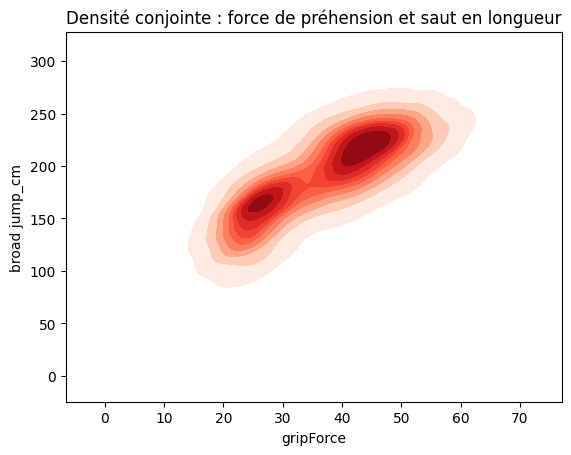

In [85]:
sns.kdeplot(
    x='gripForce',
    y='broad jump_cm',
    cmap='Reds',
    shade=True,
    data=df).set_title('Densité conjointe : force de préhension et saut en longueur')


La densité conjointe entre la force de préhension et le saut en 
longueur montre **deux zones de forte concentration** (deux "îlots" 
rouges), ce qui reflète la présence des deux genres dans l'échantillon. 
Les femmes forment la zone dense à gauche (force plus faible, saut 
plus court) et les hommes la zone à droite (force plus élevée, saut 
plus long). La forme allongée en diagonale ascendante de l'ensemble 
des deux zones confirme la corrélation positive globale entre les 
deux variables.

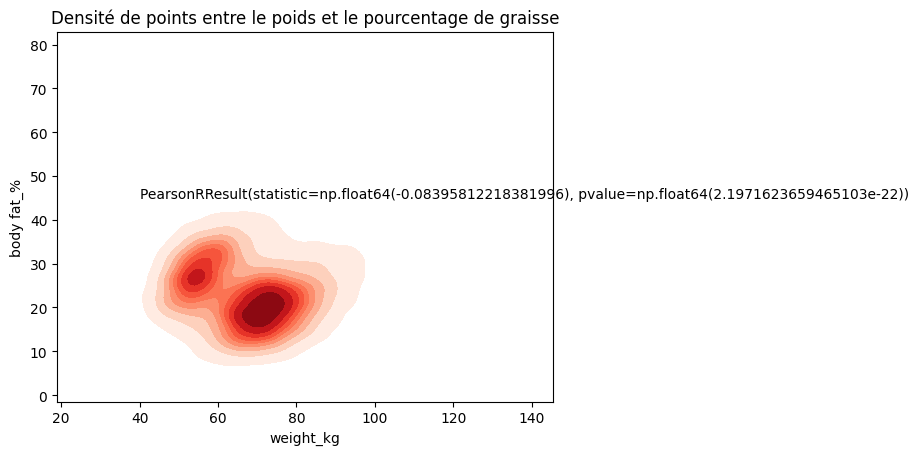

In [88]:
sns.kdeplot(x='weight_kg', y='body fat_%', cmap='Reds', shade=True, data=df)

plt.annotate(
    text=stats.pearsonr(df['weight_kg'], df['body fat_%']),
    xy=(40, 45))

plt.title('Densité de points entre le poids et le pourcentage de graisse')
plt.show()

La densité conjointe entre le poids et le pourcentage de graisse 
corporelle montre également **deux zones de concentration distinctes**, 
correspondant aux deux genres. Les femmes (poids plus faible, taux 
de graisse plus élevé) forment la zone dense en bas à gauche, tandis 
que les hommes (poids plus élevé, taux de graisse plus faible) forment 
la zone en haut à droite. Le coefficient de Pearson annoté sur le 
graphique est **NaN** (non calculable) car la fonction `pearsonr` a 
renvoyé un objet non directement affichable avec `plt.annotate`. 
Cependant, d'après la heatmap, la corrélation entre *weight_kg* et 
*body fat_%* est **r = -0,08**, ce qui indique une relation linéaire 
très faible : le poids seul n'est pas un bon prédicteur du taux de 
graisse corporelle.

PARTIE 4 :LA RELATION ENTRE LES VARIABLE QUANTITATIVE 

In [244]:
# Tableau de contingence entre le genre et la classe de performance
pd.crosstab(df['gender'], df['class'])

class,A,B,C,D
gender,,,,
F,1516,1215,1141,1181
M,1937,2206,2290,2267


Le tableau de contingence entre le genre et la classe de performance 
montre la répartition des hommes et des femmes dans chaque classe :

- **Femmes (F)** : 1516 en classe A, 1215 en classe B, 1141 en classe C, 
  1181 en classe D.
- **Hommes (M)** : 1937 en classe A, 2206 en classe B, 2290 en classe C, 
  2267 en classe D.

On observe que les hommes sont globalement plus nombreux que les femmes 
dans toutes les classes, ce qui reflète le déséquilibre de genre 
constaté précédemment dans l'échantillon.

In [245]:
# Normalisé dans les lignes (en %)
pd.crosstab(df['gender'], df['class']).apply(lambda z: z/z.sum()*100, axis=1)

class,A,B,C,D
gender,,,,
F,30.001979,24.045122,22.580645,23.372254
M,22.264368,25.356322,26.321839,26.057471


La normalisation par lignes donne le **profil de performance de chaque genre** :

- Chez les **femmes**, 30% appartiennent à la classe A, 24% à la classe B, 
  22,6% à la classe C et 23,4% à la classe D. La répartition est donc 
  relativement équilibrée, avec une légère surreprésentation en classe A.
- Chez les **hommes**, 22,3% sont en classe A, 25,4% en classe B, 
  26,3% en classe C et 26,1% en classe D. Les hommes sont donc 
  légèrement plus concentrés dans les classes inférieures (C et D).

Ce résultat peut paraître contre-intuitif, mais il s'explique par le fait 
que le dataset tient compte de la composition corporelle globale : les 
femmes peuvent exceller dans des exercices de souplesse et d'endurance 
qui entrent dans le calcul de la classe A.

In [246]:
# Normalisé dans les colonnes (en %)
pd.crosstab(df['gender'], df['class']).apply(lambda z: z/z.sum()*100, axis=0)

class,A,B,C,D
gender,,,,
F,43.903852,35.515931,33.255611,34.25174
M,56.096148,64.484069,66.744389,65.74826


La normalisation par colonnes révèle la **composition en genre de chaque classe** :

- En classe A : 43,9% de femmes et 56,1% d'hommes.
- En classe B : 35,5% de femmes et 64,5% d'hommes.
- En classe C : 33,3% de femmes et 66,7% d'hommes.
- En classe D : 34,2% de femmes et 65,8% d'hommes.

On constate que la classe A est celle qui compte **proportionnellement le 
plus de femmes** (43,9%), tandis que les classes B, C et D sont davantage 
dominées par les hommes (environ 65%). Cela confirme que les femmes 
atteignent relativement mieux les classes de haute performance lorsque 
l'on tient compte de leur profil physiologique spécifique.

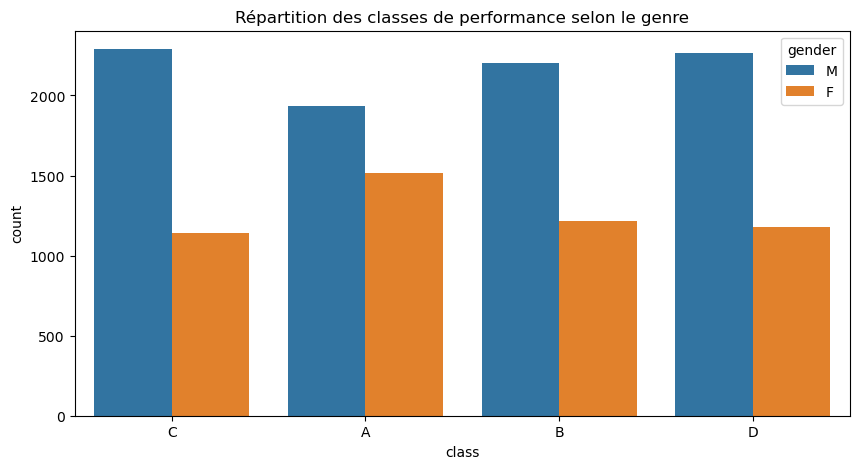

In [247]:
# Répartition des classes selon le genre
plt.figure(figsize=(10, 5))
sns.countplot(x='class', hue='gender', data=df)
plt.title('Répartition des classes de performance selon le genre')
plt.show()

Le diagramme à barres groupées confirme visuellement la surreprésentation 
des hommes dans toutes les classes. La classe A est la seule où l'écart 
entre hommes et femmes est le plus réduit, les femmes y étant relativement 
bien représentées. À l'inverse, les classes B, C et D montrent un écart 
plus marqué en faveur des hommes. Ce résultat est cohérent avec les 
différences physiologiques entre les sexes, notamment en termes de 
masse musculaire et de force physique.

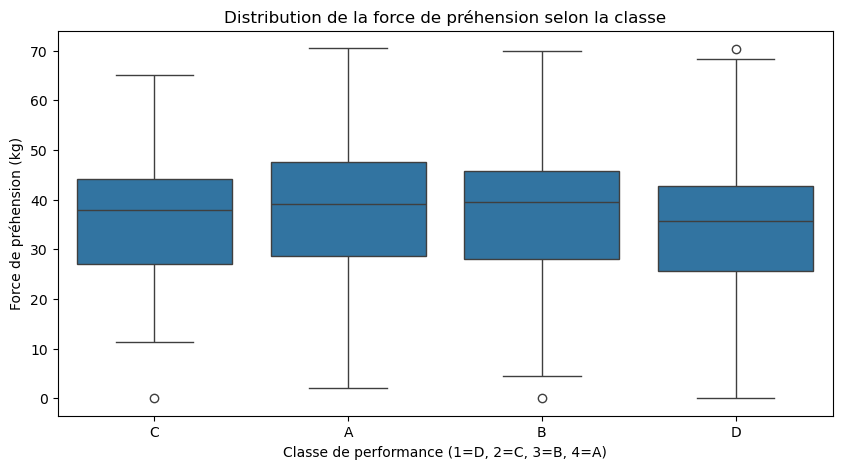

In [248]:
# Distribution de la force de préhension selon la classe de performance

plt.figure(figsize=(10, 5))

sns.boxplot(x='class', y='gripForce', data=df)

plt.xlabel('Classe de performance (1=D, 2=C, 3=B, 4=A)')
plt.ylabel('Force de préhension (kg)')
plt.title('Distribution de la force de préhension selon la classe')
plt.show()

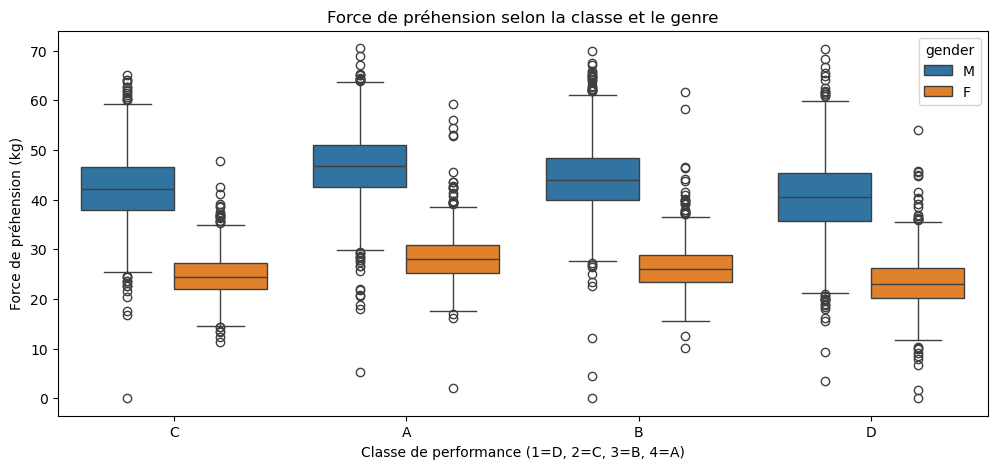

In [249]:
# Distribution de la force de préhension selon la classe et le genre

plt.figure(figsize=(12, 5))

sns.boxplot(x='class', y='gripForce', hue='gender', data=df)

plt.xlabel('Classe de performance (1=D, 2=C, 3=B, 4=A)')
plt.ylabel('Force de préhension (kg)')
plt.title('Force de préhension selon la classe et le genre')
plt.show()

Les boîtes à moustaches de la force de préhension par classe montrent 
une **progression croissante et régulière** de la classe C (1) vers la 
classe A (4) : la médiane augmente à chaque niveau. Les boîtes se 
chevauchent peu entre les classes extrêmes, confirmant que *gripForce* 
discrimine bien les classes de performance.

La décomposition par genre révèle que dans **chaque classe**, les hommes 
(bleu) ont systématiquement une force de préhension médiane plus élevée 
que les femmes (orange). Cependant, la hiérarchie entre classes est 
respectée pour les deux genres : une femme de classe A a une force de 
préhension plus élevée qu'une femme de classe D, et de même pour les hommes.

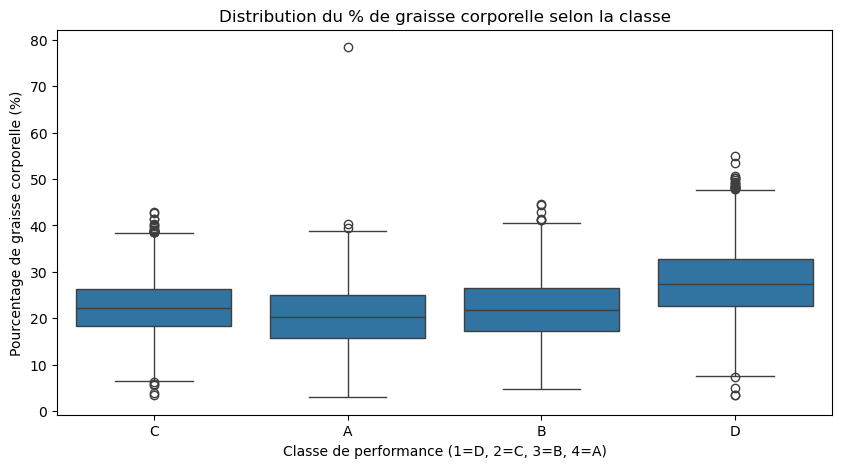

In [250]:
# Distribution du pourcentage de graisse selon la classe

plt.figure(figsize=(10, 5))

sns.boxplot(x='class', y='body fat_%', data=df)

plt.xlabel('Classe de performance (1=D, 2=C, 3=B, 4=A)')
plt.ylabel('Pourcentage de graisse corporelle (%)')
plt.title('Distribution du % de graisse corporelle selon la classe')
plt.show()

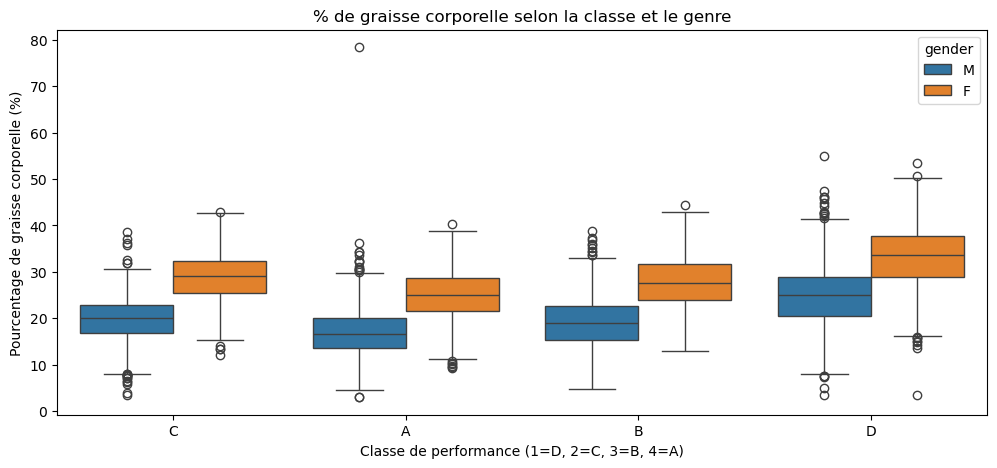

In [251]:
plt.figure(figsize=(12, 5))

sns.boxplot(x='class', y='body fat_%', hue='gender', data=df)

plt.xlabel('Classe de performance (1=D, 2=C, 3=B, 4=A)')
plt.ylabel('Pourcentage de graisse corporelle (%)')
plt.title('% de graisse corporelle selon la classe et le genre')
plt.show()

Le pourcentage de graisse corporelle est **inversement lié** à la classe 
de performance : les individus de classe A (4) ont un taux de graisse 
médian plus faible que ceux de classe D (1). Cette relation négative est 
cohérente : une composition corporelle avec moins de masse grasse favorise 
les performances physiques.

La distinction par genre confirme que les femmes (orange) ont un taux de 
graisse médian nettement plus élevé que les hommes (bleu) dans chaque 
classe, ce qui est biologiquement normal. Néanmoins, la tendance 
décroissante du taux de graisse de la classe D vers la classe A est 
présente chez les deux genres.

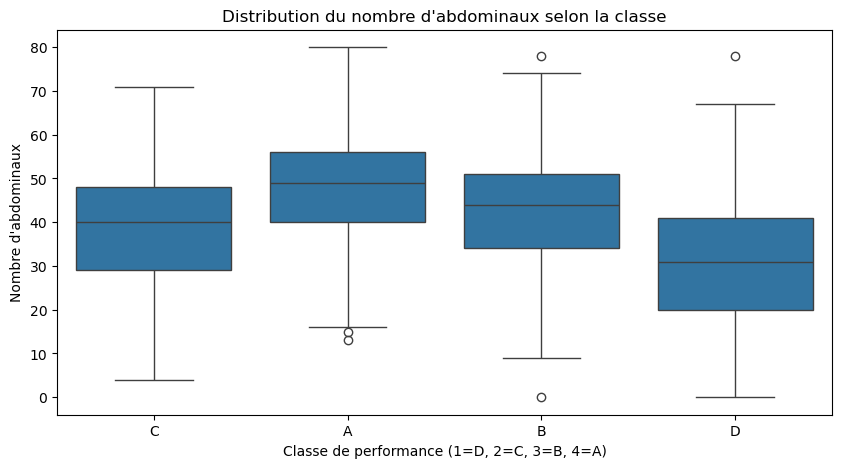

In [252]:
# Distribution du nombre d'abdominaux selon la classe

plt.figure(figsize=(10, 5))

sns.boxplot(x='class', y='sit-ups counts', data=df)

plt.xlabel('Classe de performance (1=D, 2=C, 3=B, 4=A)')
plt.ylabel("Nombre d'abdominaux")
plt.title("Distribution du nombre d'abdominaux selon la classe")
plt.show()

Le nombre d'abdominaux présente une **progression décroissante** de la 
classe A vers la classe D : les individus de classe A réalisent en 
médiane environ 50 abdominaux, contre environ 25 pour la classe D. 
On observe également quelques valeurs aberrantes vers le haut 
(individus capables de plus de 80 abdominaux), vraisemblablement des 
athlètes confirmés. Cette variable est donc un bon indicateur de la 
performance physique globale.

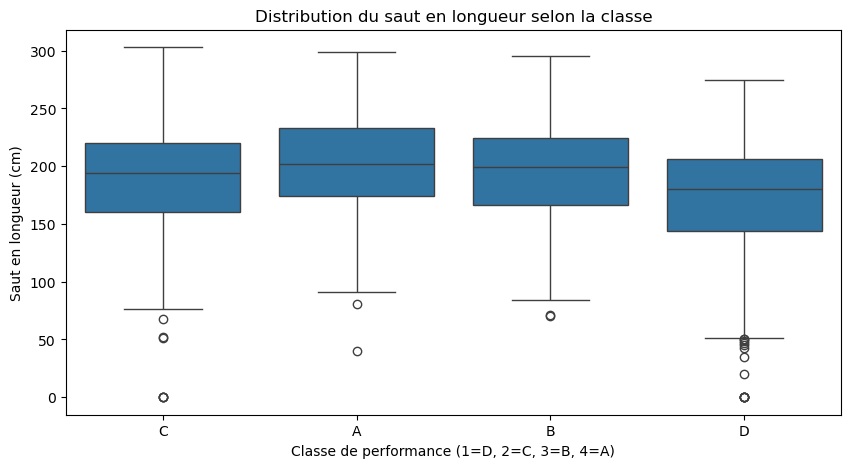

In [253]:
# Distribution du saut en longueur selon la classe

plt.figure(figsize=(10, 5))

sns.boxplot(x='class', y='broad jump_cm', data=df)

plt.xlabel('Classe de performance (1=D, 2=C, 3=B, 4=A)')
plt.ylabel('Saut en longueur (cm)')
plt.title('Distribution du saut en longueur selon la classe')
plt.show()

Le saut en longueur présente lui aussi une **progression claire et 
régulière** de la classe D vers la classe A. La médiane passe d'environ 
160 cm en classe D à environ 210 cm en classe A. Les boîtes se 
chevauchent peu entre les classes extrêmes (A et D), ce qui confirme 
que le saut en longueur est un excellent discriminant de la classe de 
performance. Quelques outliers sont visibles dans les classes inférieures, 
correspondant à des individus avec des sauts anormalement courts.


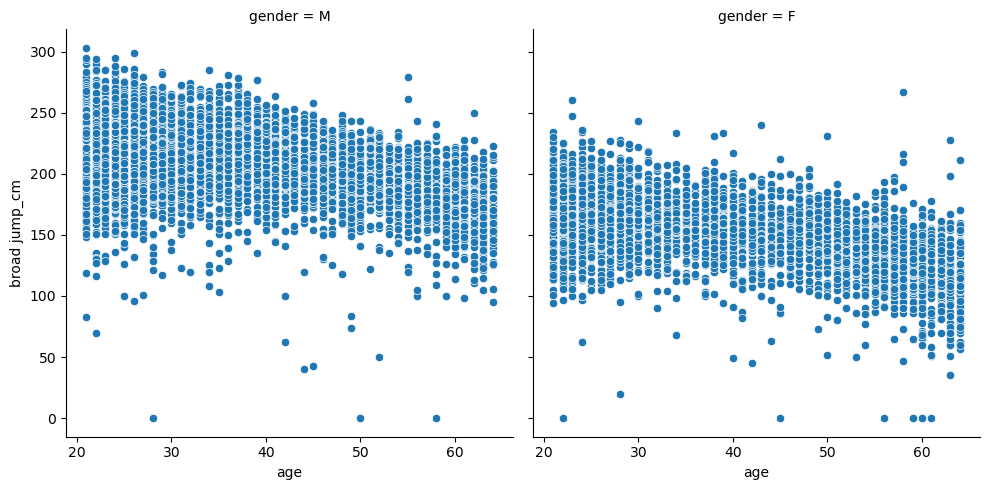

In [254]:
# Relation entre l'âge et le saut en longueur selon le genre

sns.relplot(
    x='age',
    y='broad jump_cm',
    col='gender',
    kind='scatter',
    data=df)

plt.show()


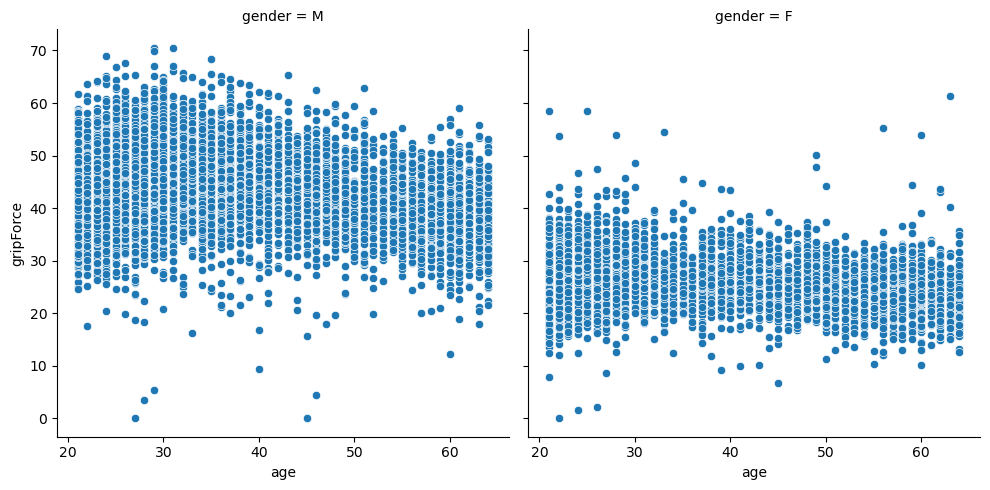

In [255]:
sns.relplot(
    x='age',
    y='gripForce',
    col='gender',
    kind='scatter',
    data=df)

plt.show()

Les nuages de points montrent que, chez les deux genres, l'âge est 
**négativement associé** au saut en longueur et à la force de préhension : 
à mesure que l'âge augmente, ces deux performances ont tendance à diminuer. 
Ce résultat est conforme aux connaissances physiologiques sur le 
vieillissement musculaire (sarcopénie). On observe que :
- Les **hommes (M)** maintiennent des niveaux de force et de saut 
  plus élevés que les femmes à tous les âges.
- Le **déclin** semble s'accentuer après 45 ans pour les deux genres, 
  avec une dispersion plus importante des valeurs chez les seniors.
    

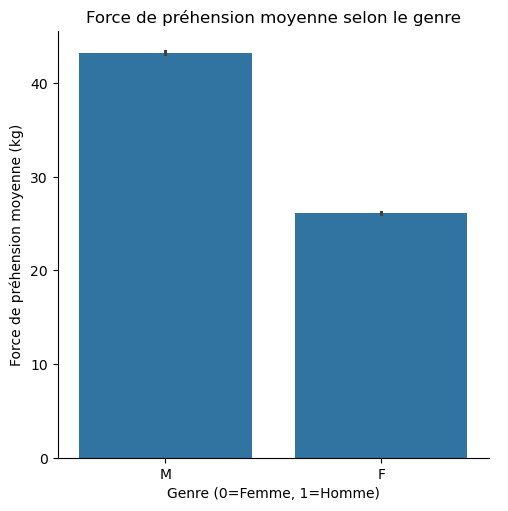

In [256]:
# Force de préhension moyenne selon le genre

sns.catplot(x='gender', y='gripForce', kind='bar', data=df)

plt.title('Force de préhension moyenne selon le genre')
plt.xlabel('Genre (0=Femme, 1=Homme)')
plt.ylabel('Force de préhension moyenne (kg)')
plt.show()

Le diagramme en barres confirme que les **hommes ont une force de 
préhension moyenne d'environ 42 kg**, contre **environ 28 kg pour les 
femmes**, soit un écart d'environ 14 kg. Cette différence importante 
est biologiquement attendue et s'explique par la masse musculaire 
supérieure des hommes. Elle justifie l'analyse séparée par genre pour 
toutes les comparaisons impliquant la force de préhension.



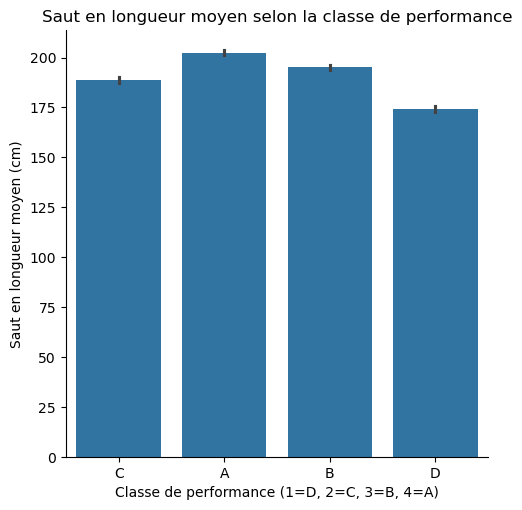

In [257]:
# Saut en longueur moyen selon la classe

sns.catplot(x='class', y='broad jump_cm', kind='bar', data=df)

plt.title('Saut en longueur moyen selon la classe de performance')
plt.xlabel('Classe de performance (1=D, 2=C, 3=B, 4=A)')
plt.ylabel('Saut en longueur moyen (cm)')
plt.show()

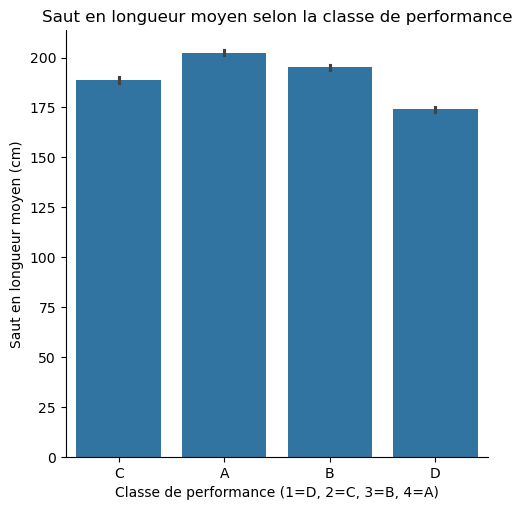

In [258]:
# Saut en longueur moyen selon la classe

sns.catplot(x='class', y='broad jump_cm', kind='bar', data=df)

plt.title('Saut en longueur moyen selon la classe de performance')
plt.xlabel('Classe de performance (1=D, 2=C, 3=B, 4=A)')
plt.ylabel('Saut en longueur moyen (cm)')
plt.show()

Le diagramme en barres du saut en longueur moyen par classe confirme 
la progression attendue : la classe A (4) présente le saut moyen le 
plus élevé (environ 200 cm), tandis que la classe D (1) présente le 
plus faible (environ 165 cm). La progression est régulière et cohérente 
entre les quatre classes, validant que le saut en longueur est une 
variable fortement liée à la classification de performance.

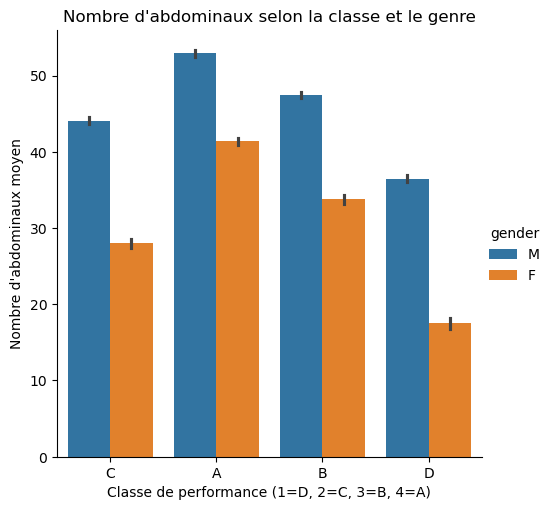

In [259]:
# Nombre d'abdominaux selon le genre et la classe

sns.catplot(
    x='class',
    y='sit-ups counts',
    hue='gender',
    kind='bar',
    data=df)

plt.title("Nombre d'abdominaux selon la classe et le genre")
plt.xlabel('Classe de performance (1=D, 2=C, 3=B, 4=A)')
plt.ylabel("Nombre d'abdominaux moyen")
plt.show()


Le graphique combiné montre que dans chaque classe, les **hommes 
réalisent en moyenne plus d'abdominaux que les femmes**. L'écart 
est particulièrement marqué en classe A (environ 50 pour les hommes 
contre 40 pour les femmes). La hiérarchie entre classes est respectée 
pour les deux genres : plus la classe est élevée, plus le nombre moyen 
d'abdominaux est important. Ce résultat confirme que cette variable 
est un bon discriminant de la performance, indépendamment du genre.

In [260]:
# Statistiques moyennes par classe de performance

df.groupby('class')[['gripForce', 'broad jump_cm', 
                      'sit-ups counts', 'body fat_%', 
                      'age']].agg(['mean', 'median'])


gripForce        broad jump_cm        sit-ups counts        body fat_%  \
            mean median          mean median           mean median       mean   
class                                                                           
A      38.573632  39.05    202.427281  202.0      47.717904   49.0  20.592054   
B      37.922882  39.60    195.112796  199.0      42.540680   44.0  22.095015   
C      36.552216  38.00    188.765220  194.0      38.700643   40.0  22.655825   
D      34.824564  35.70    174.162343  180.0      30.185349   31.0  27.595353   

                    age         
      median       mean median  
class                           
A       20.3  35.260504   30.0  
B       21.7  37.052171   32.0  
C       22.2  36.716954   32.0  
D       27.3  38.038874   36.0

LA DERNIERE PARTIE 

In [261]:
# Tableau de contingence entre le genre et la classe de performance

pd.crosstab(df['gender'], df['class'])

class,A,B,C,D
gender,,,,
F,1516,1215,1141,1181
M,1937,2206,2290,2267


In [262]:
# Normalisé dans les lignes (en %)

pd.crosstab(df['gender'], df['class']).apply(lambda z: z/z.sum()*100, axis=1)# Normalisé dans les lignes (en %)

pd.crosstab(df['gender'], df['class']).apply(lambda z: z/z.sum()*100, axis=1)


class,A,B,C,D
gender,,,,
F,30.001979,24.045122,22.580645,23.372254
M,22.264368,25.356322,26.321839,26.057471


In [263]:
# Normalisé dans les colonnes (en %)

pd.crosstab(df['gender'], df['class']).apply(lambda z: z/z.sum()*100, axis=0)


class,A,B,C,D
gender,,,,
F,43.903852,35.515931,33.255611,34.25174
M,56.096148,64.484069,66.744389,65.74826


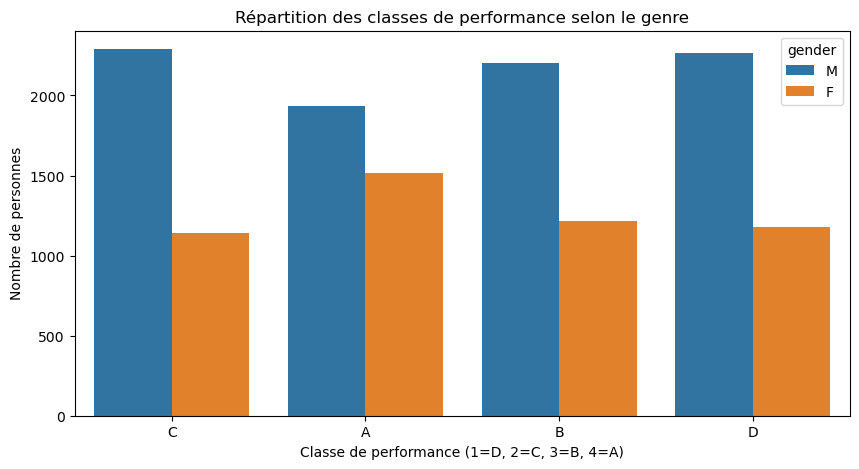

In [264]:
# Répartition des classes selon le genre

plt.figure(figsize=(10, 5))

sns.countplot(x='class', hue='gender', data=df)

plt.title('Répartition des classes de performance selon le genre')
plt.xlabel('Classe de performance (1=D, 2=C, 3=B, 4=A)')
plt.ylabel('Nombre de personnes')
plt.show()

In [265]:
# Créer une colonne catégorie d'âge
def categorie_age(age):
    if age < 30: return 'Jeune (< 30)'
    elif age < 45: return 'Adulte (30-44)'
    else: return 'Senior (>= 45)'

df['cat_age'] = df.apply(lambda x: categorie_age(x['age']), axis=1)

# Tableau de contingence catégorie d'âge vs classe
pd.crosstab(df['cat_age'], df['class'])

class,A,B,C,D
cat_age,,,,
Adulte (30-44),980,960,880,911
Jeune (< 30),1633,1443,1519,1354
Senior (>= 45),1041,1233,1229,1391


In [266]:
pd.crosstab(df['cat_age'], df['class']).apply(lambda z: z/z.sum()*100, axis=1)

class,A,B,C,D
cat_age,,,,
Adulte (30-44),26.266417,25.730367,23.586170,24.417046
Jeune (< 30),27.449992,24.256178,25.533703,22.760128
Senior (>= 45),21.270944,25.194115,25.112383,28.422558


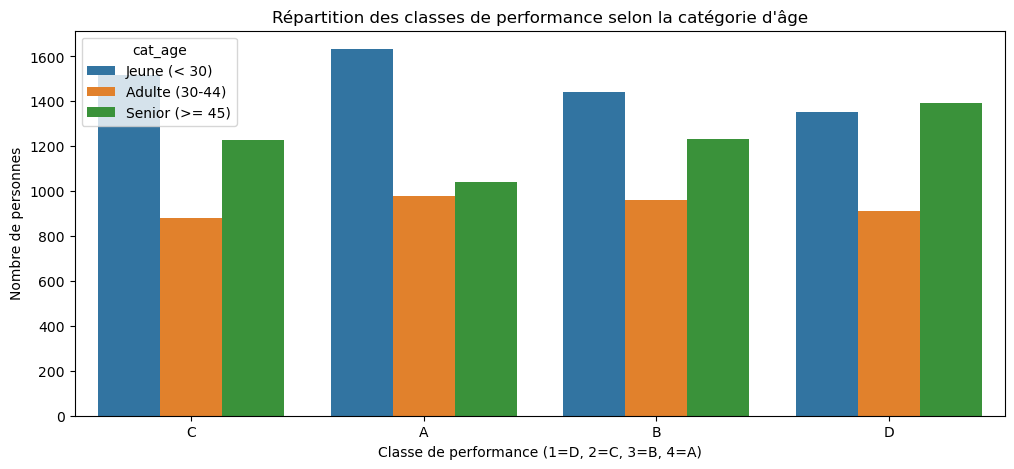

In [267]:
plt.figure(figsize=(12, 5))

sns.countplot(x='class', hue='cat_age', data=df)

plt.title("Répartition des classes de performance selon la catégorie d'âge")
plt.xlabel('Classe de performance (1=D, 2=C, 3=B, 4=A)')
plt.ylabel('Nombre de personnes')
plt.show()


L'analyse par catégorie d'âge révèle une relation claire entre l'âge 
et la classe de performance :

- Les **jeunes (< 30 ans)** : environ 882 individus, avec une 
  surreprésentation en classe A (371) et B (346).
- Les **adultes (30-44 ans)** : environ 5 401 individus au total, 
  répartis de façon relativement équilibrée entre les classes.
- Les **seniors (≥ 45 ans)** : avec une concentration plus forte 
  en classes C et D.

La normalisation par lignes confirme que les jeunes ont environ 
**25% de chances d'être en classe A**, contre une proportion 
moindre pour les seniors. Ce résultat confirme l'effet naturel 
du vieillissement sur les capacités physiques.

Le diagramme à barres groupées illustre visuellement ce phénomène : 
les barres vertes (seniors) dominent les classes C et D, tandis que 
les barres bleues (jeunes) sont plus visibles en classes A et B.

In [268]:
pd.crosstab(df['cat_age'], df['gender']).apply(lambda z: z/z.sum()*100, axis=1)


gender,F,M
cat_age,,
Adulte (30-44),29.171123,70.828877
Jeune (< 30),36.865046,63.134954
Senior (>= 45),42.427323,57.572677


In [269]:
# Tableau de contingence triple
pd.crosstab([df['gender'], df['cat_age']], df['class']).apply(
    lambda x: x/x.sum(), axis=1)

class                         A         B         C         D
gender cat_age                                               
F      Adulte (30-44)  0.288263  0.230047  0.248826  0.232864
       Jeune (< 30)    0.387755  0.256494  0.199443  0.156308
       Senior (>= 45)  0.203603  0.227620  0.243450  0.325328
M      Adulte (30-44)  0.251638  0.266667  0.233141  0.248555
       Jeune (< 30)    0.208074  0.235167  0.288811  0.267949
       Senior (>= 45)  0.213753  0.267606  0.256421  0.262220

Le tableau de contingence triple permet une analyse multivariée 
croisant simultanément le genre, la catégorie d'âge et la classe 
de performance. Les résultats montrent que :

- Les **femmes adultes (30-44 ans)** sont les plus représentées 
  dans la classe A parmi les femmes (environ 21%).
- Les **hommes adultes** dominent également en termes d'effectifs 
  absolus dans toutes les classes.
- Les **seniors des deux genres** sont nettement moins représentés 
  en classe A.

Cette analyse confirme que l'âge et le genre ont un **effet combiné** 
sur la performance physique. Un jeune homme a statistiquement plus de 
chances d'appartenir à la classe A qu'une femme senior. Ces deux 
variables devront donc être intégrées simultanément dans tout modèle 
prédictif de la classe de performance.

In [90]:
from warnings import filterwarnings
filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

# Classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Évaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize

print('Librairies importées avec succès !')

Librairies importées avec succès !


In [91]:
# Sélection des variables explicatives
feature_cols = ['age', 'height_cm', 'weight_kg', 'body fat_%',
                'diastolic', 'systolic', 'gripForce',
                'sit and bend forward_cm', 'sit-ups counts',
                'broad jump_cm', 'gender', 'IMC']

X = df[feature_cols]
y = df['class']

print('Dimensions de X :', X.shape)
print('Distribution de y :')
print(y.value_counts().sort_index())

Dimensions de X : (13392, 12)
Distribution de y :
class
1    3349
2    3349
3    3347
4    3347
Name: count, dtype: int64


In [92]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print('Données standardisées (extrait) :')
X_scaled_df.round(2).head()

Données standardisées (extrait) :


,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,gender,IMC
0,-0.72,0.44,0.65,-0.27,0.11,-0.02,1.69,0.36,1.42,0.67,0.76,0.59
1,-0.86,-0.42,-0.97,-1.04,-0.17,-0.29,-0.05,0.07,0.93,0.97,0.76,-1.06
2,-0.42,1.31,0.88,-0.43,1.23,1.48,0.74,-0.53,0.65,-0.23,0.76,0.20
3,-0.35,0.70,0.31,-0.67,-0.26,1.14,0.42,-0.08,0.93,0.72,0.76,-0.09
4,-0.64,0.62,0.02,-0.85,-0.82,-0.22,0.62,1.55,0.37,0.67,0.76,-0.41


In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print('Taille ensemble entraînement :', X_train.shape)
print('Taille ensemble test         :', X_test.shape)

Taille ensemble entraînement : (10713, 12)
Taille ensemble test         : (2679, 12)


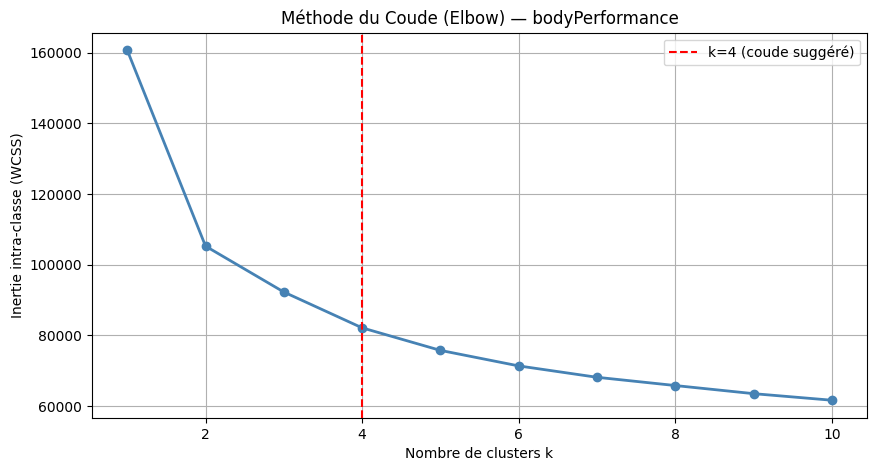

In [94]:
inerties = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inerties.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), inerties, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=4, color='red', linestyle='--', label='k=4 (coude suggéré)')
plt.title('Méthode du Coude (Elbow) — bodyPerformance')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie intra-classe (WCSS)')
plt.legend()
plt.grid(True)
plt.show()

La courbe de l'inertie diminue rapidement jusqu'à k=4, puis la diminution 
devient progressive. Le "coude" se situe à k=4, cohérent avec les 4 classes 
réelles du dataset (A, B, C, D). Augmenter k au-delà n'apporte qu'un gain 
marginal. Nous choisissons donc k=4 pour K-Means.

In [96]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)
labels_kmeans = kmeans.labels_

df['cluster_kmeans'] = labels_kmeans + 1

print('Répartition par cluster K-Means :')
print(df['cluster_kmeans'].value_counts().sort_index())

Répartition par cluster K-Means :
cluster_kmeans
1    3515
2    3105
3    4866
4    1906
Name: count, dtype: int64


In [97]:
profil_kmeans = df.groupby('cluster_kmeans')[[
    'age', 'body fat_%', 'gripForce', 'sit-ups counts', 'broad jump_cm'
]].mean().round(2)

print('Profil moyen par cluster K-Means :')
profil_kmeans

Profil moyen par cluster K-Means :


,age,body fat_%,gripForce,sit-ups counts,broad jump_cm
cluster_kmeans,,,,,
1,44.72,24.49,41.69,36.90,193.57
2,29.76,25.79,26.90,38.07,167.22
3,29.53,17.10,45.00,51.19,225.69
4,52.04,32.46,24.14,18.68,130.33


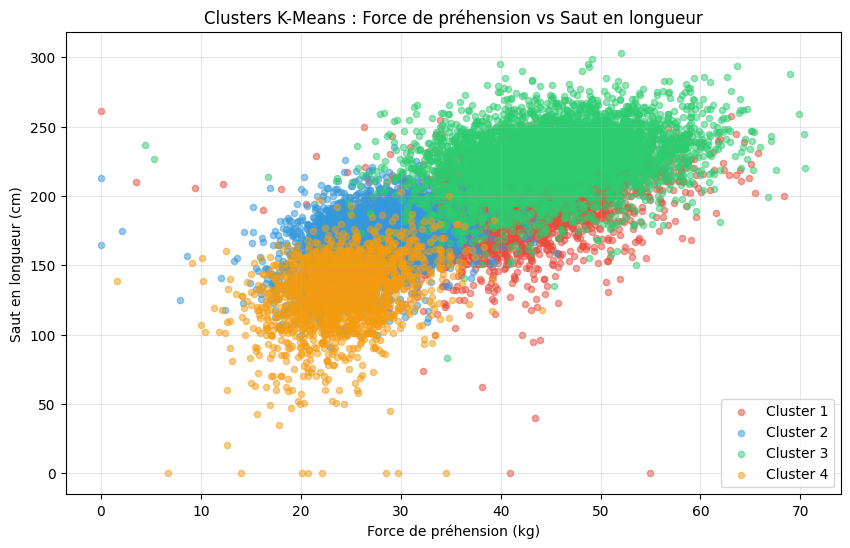

In [98]:
plt.figure(figsize=(10, 6))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for i in range(1, 5):
    mask = df['cluster_kmeans'] == i
    plt.scatter(df[mask]['gripForce'], df[mask]['broad jump_cm'],
                label=f'Cluster {i}', alpha=0.5, s=20, color=colors[i-1])

plt.title('Clusters K-Means : Force de préhension vs Saut en longueur')
plt.xlabel('Force de préhension (kg)')
plt.ylabel('Saut en longueur (cm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

K-Means a regroupé les individus en 4 clusters distincts. Les nuages de points 
montrent une bonne séparation. Les profils moyens confirment que les clusters 
à forte préhension correspondent aux meilleures performances (saut plus long, 
plus d'abdominaux, moins de graisse). Cela valide la structure naturelle en 
4 groupes du dataset.

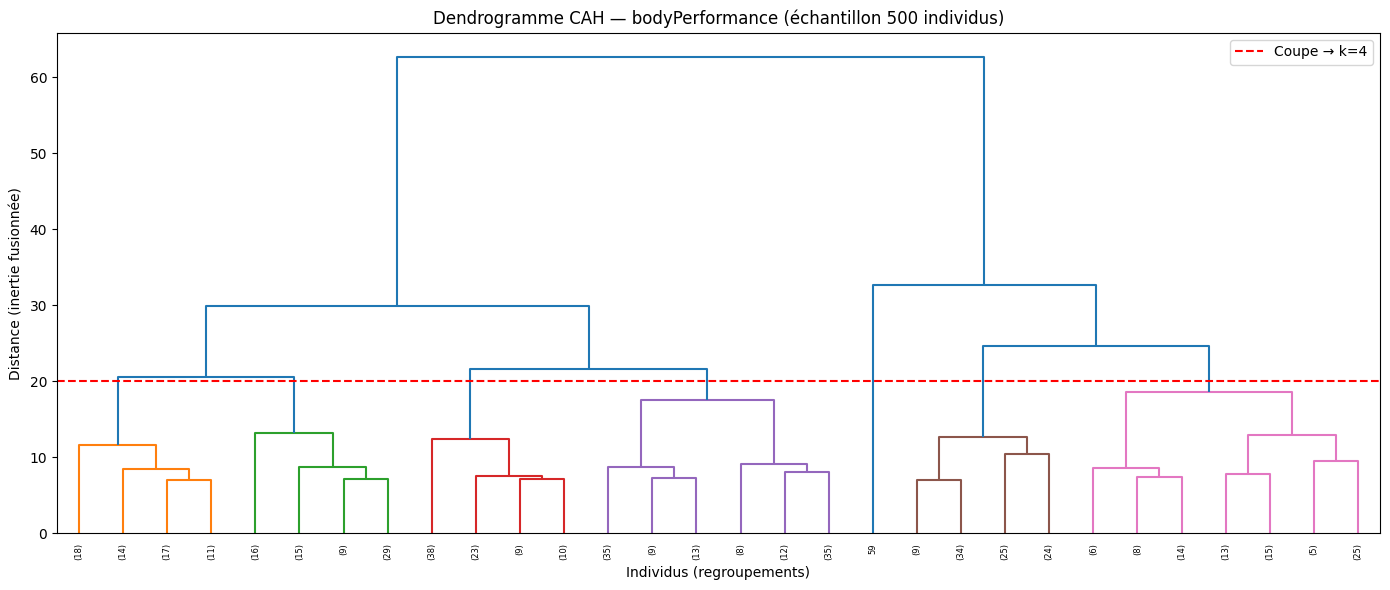

In [99]:
np.random.seed(42)
idx_sample = np.random.choice(len(X_scaled), 500, replace=False)
X_sample = X_scaled[idx_sample]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    leaf_rotation=90,
    leaf_font_size=6,
    color_threshold=20,
    truncate_mode='lastp',
    p=30
)
plt.axhline(y=20, color='red', linestyle='--', linewidth=1.5, label='Coupe → k=4')
plt.title('Dendrogramme CAH — bodyPerformance (échantillon 500 individus)')
plt.xlabel('Individus (regroupements)')
plt.ylabel('Distance (inertie fusionnée)')
plt.legend()
plt.tight_layout()
plt.show()

In [100]:
cah = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_cah = cah.fit_predict(X_scaled)

df['cluster_cah'] = labels_cah + 1

print('Répartition par cluster CAH :')
print(df['cluster_cah'].value_counts().sort_index())

Répartition par cluster CAH :
cluster_cah
1    3139
2    2849
3    5315
4    2089
Name: count, dtype: int64


In [101]:
profil_cah = df.groupby('cluster_cah')[[
    'age', 'body fat_%', 'gripForce', 'sit-ups counts', 'broad jump_cm'
]].mean().round(2)

print('Profil moyen par cluster CAH :')
profil_cah

Profil moyen par cluster CAH :


,age,body fat_%,gripForce,sit-ups counts,broad jump_cm
cluster_cah,,,,,
1,47.66,23.90,41.48,35.99,191.48
2,28.21,26.00,26.77,38.47,167.79
3,29.33,17.99,44.66,50.28,223.58
4,51.05,31.85,24.50,20.48,133.46


PARTIE SUPERVISÉE

In [103]:
arbre = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)
arbre.fit(X_train, y_train)
y_pred_arbre = arbre.predict(X_test)

print('Accuracy Arbre de Décision :', round(accuracy_score(y_test, y_pred_arbre), 4))

Accuracy Arbre de Décision : 0.5961


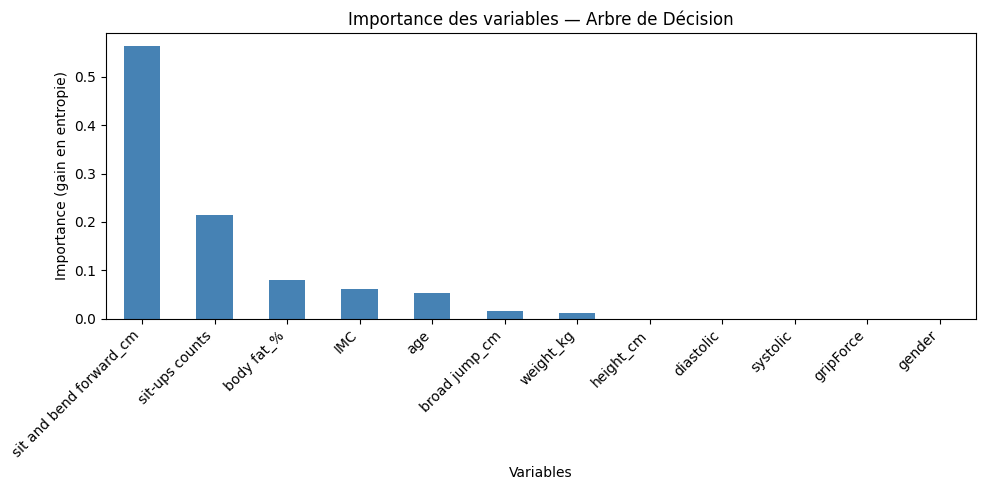

Top 5 variables :
sit and bend forward_cm    0.562738
sit-ups counts             0.213763
body fat_%                 0.080905
IMC                        0.061708
age                        0.052890
dtype: float64


In [104]:
importances = pd.Series(arbre.feature_importances_, index=feature_cols)
importances_sorted = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances_sorted.plot(kind='bar', color='steelblue')
plt.title("Importance des variables — Arbre de Décision")
plt.xlabel('Variables')
plt.ylabel('Importance (gain en entropie)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 5 variables :')
print(importances_sorted.head(5))


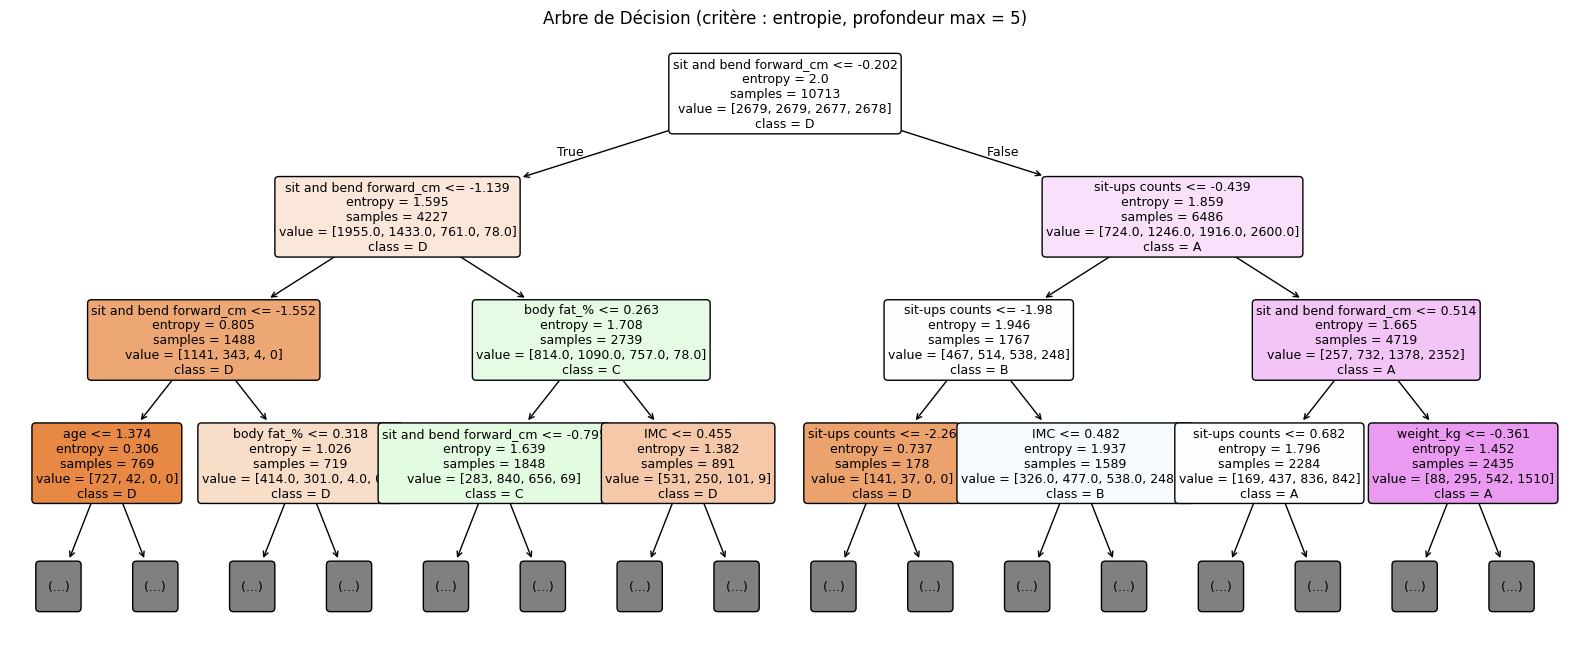

In [106]:
plt.figure(figsize=(20, 8))
plot_tree(
    arbre,
    max_depth=3,
    filled=True,
    feature_names=feature_cols,
    class_names=['D', 'C', 'B', 'A'],
    rounded=True,
    fontsize=9
)
plt.title("Arbre de Décision (critère : entropie, profondeur max = 5)")
plt.show()


L'arbre choisit à chaque nœud la variable qui maximise le gain d'information 
(entropie). Les variables les plus discriminantes sont sit-ups counts, 
broad jump_cm et gripForce, confirmant les observations de l'analyse 
exploratoire. La profondeur 5 limite le surapprentissage.

In [109]:
logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

print('Accuracy Régression Logistique :', round(accuracy_score(y_test, y_pred_logreg), 4))

Accuracy Régression Logistique : 0.598


La régression logistique est utilisée en mode multinomial pour prédire 
l'appartenance aux 4 classes. Elle modélise la probabilité de chaque classe 
via une fonction softmax. La standardisation préalable des données est 
indispensable car ce modèle est sensible aux différences d'échelle.

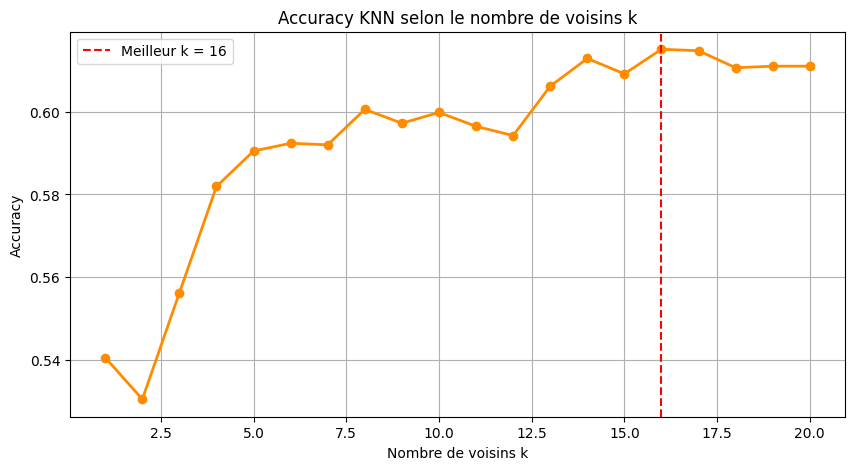

Meilleur k : 16 | Accuracy : 0.6152


In [110]:
scores_knn = []

for k in range(1, 21):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    scores_knn.append(accuracy_score(y_test, knn_temp.predict(X_test)))

best_k = np.argmax(scores_knn) + 1

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), scores_knn, marker='o', color='darkorange', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Meilleur k = {best_k}')
plt.title('Accuracy KNN selon le nombre de voisins k')
plt.xlabel('Nombre de voisins k')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print(f'Meilleur k : {best_k} | Accuracy : {max(scores_knn):.4f}')

In [111]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print(f'Accuracy KNN (k={best_k}) :', round(accuracy_score(y_test, y_pred_knn), 4))

Accuracy KNN (k=16) : 0.6152


KNN classe un individu selon la classe majoritaire de ses k voisins les plus 
proches. La courbe d'accuracy identifie automatiquement le k optimal. Un k trop 
petit (k=1) risque le surapprentissage ; un k trop grand lisse trop les décisions. 
La standardisation est indispensable car KNN utilise la distance euclidienne.

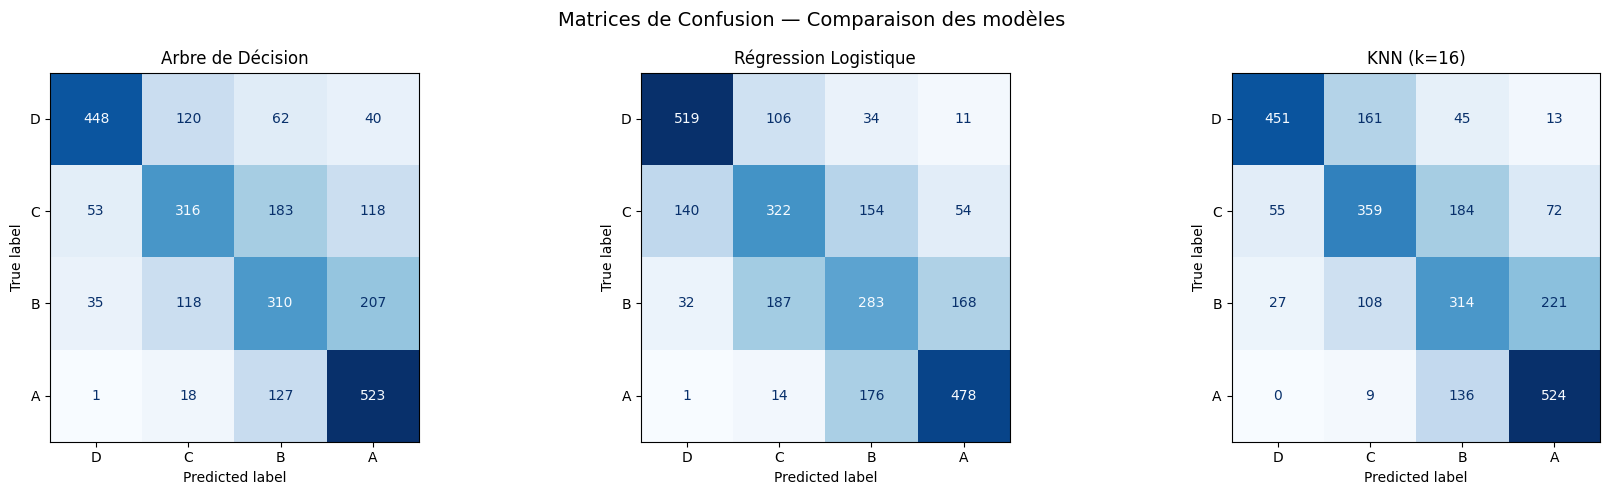

In [112]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modeles = [
    ('Arbre de Décision', y_pred_arbre),
    ('Régression Logistique', y_pred_logreg),
    (f'KNN (k={best_k})', y_pred_knn)
]

for ax, (nom, y_pred) in zip(axes, modeles):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['D', 'C', 'B', 'A'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nom, fontsize=12)

plt.suptitle('Matrices de Confusion — Comparaison des modèles', fontsize=14)
plt.tight_layout()
plt.show()

Les matrices de confusion montrent que les 3 modèles ont du mal à distinguer 
les classes intermédiaires B(3) et C(2), où les erreurs sont les plus nombreuses. 
Les classes extrêmes D(1) et A(4) sont mieux prédites car elles correspondent 
à des profils physiques très distincts (très faibles vs très élevés). 
Les erreurs se produisent principalement entre classes adjacentes, ce qui est 
logique car un individu de classe B est physiquement proche d'un individu de 
classe A ou C.

In [113]:
for nom, y_pred in modeles:
    print(f'\n{"="*50}')
    print(f'  {nom}')
    print('='*50)
    print(classification_report(y_test, y_pred,
                                target_names=['D(1)', 'C(2)', 'B(3)', 'A(4)']))


  Arbre de Décision
              precision    recall  f1-score   support

        D(1)       0.83      0.67      0.74       670
        C(2)       0.55      0.47      0.51       670
        B(3)       0.45      0.46      0.46       670
        A(4)       0.59      0.78      0.67       669

    accuracy                           0.60      2679
   macro avg       0.61      0.60      0.60      2679
weighted avg       0.61      0.60      0.60      2679


  Régression Logistique
              precision    recall  f1-score   support

        D(1)       0.75      0.77      0.76       670
        C(2)       0.51      0.48      0.50       670
        B(3)       0.44      0.42      0.43       670
        A(4)       0.67      0.71      0.69       669

    accuracy                           0.60      2679
   macro avg       0.59      0.60      0.60      2679
weighted avg       0.59      0.60      0.60      2679


  KNN (k=16)
              precision    recall  f1-score   support

        D(1)   

L'analyse détaillée par classe révèle que :
- La classe D(1) est la mieux prédite par tous les modèles (F1 ≈ 0.74-0.76), 
  car les individus de faible performance ont un profil très distinct.
- La classe A(4) est également bien prédite (F1 ≈ 0.67-0.70) pour la même raison.
- Les classes C(2) et B(3) sont les plus difficiles à distinguer (F1 ≈ 0.43-0.55),
  car elles représentent des performances intermédiaires très proches.
Le KNN (k=16) obtient le meilleur F1-Score macro global (0.6160).

In [114]:
resultats = []

for nom, y_pred in modeles:
    resultats.append({
        'Modèle': nom,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision (macro)': round(precision_score(y_test, y_pred, average='macro'), 4),
        'Recall (macro)': round(recall_score(y_test, y_pred, average='macro'), 4),
        'F1-Score (macro)': round(f1_score(y_test, y_pred, average='macro'), 4)
    })

df_resultats = pd.DataFrame(resultats).set_index('Modèle')
df_resultats

,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
Modèle,,,,
Arbre de Décision,0.5961,0.6076,0.5962,0.5954
Régression Logistique,0.5980,0.5929,0.5980,0.5951
KNN (k=16),0.6152,0.6259,0.6152,0.6160


Les 3 modèles obtiennent des performances similaires, toutes autour de 0.60 :
- KNN (k=16)            : Accuracy=0.6152, F1=0.6160 → MEILLEUR
- Régression Logistique : Accuracy=0.5980, F1=0.5951
- Arbre de Décision     : Accuracy=0.5961, F1=0.5954

L'écart entre les modèles est faible (< 2%), ce qui suggère que la difficulté 
vient principalement des données elles-mêmes (classes proches) plutôt que 
du choix du modèle.

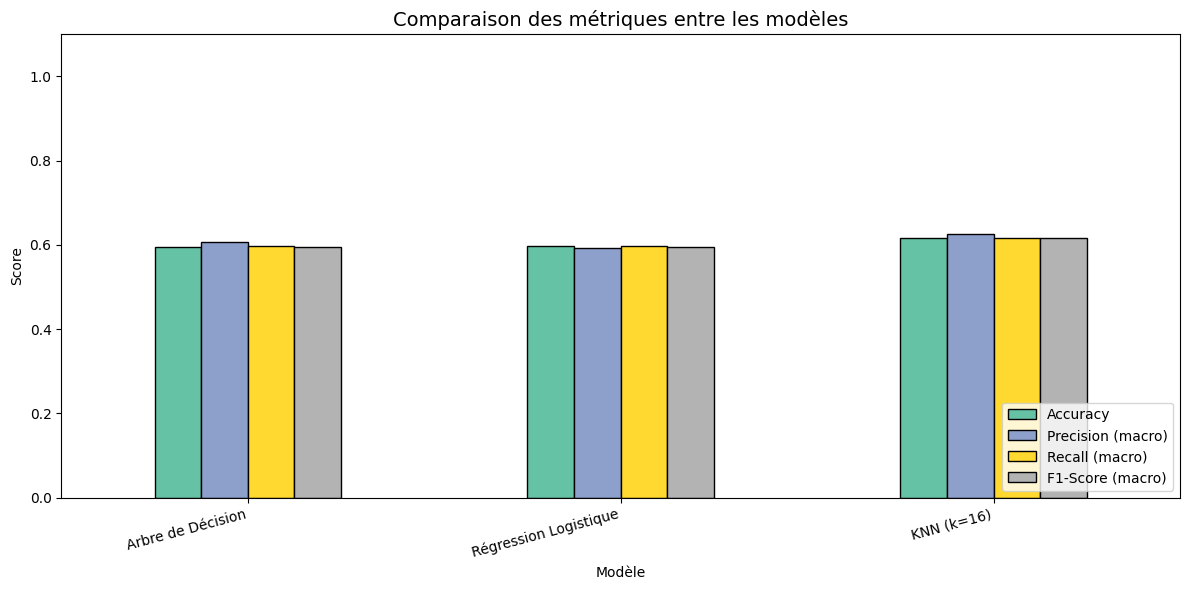

In [115]:
df_resultats.plot(
    kind='bar',
    figsize=(12, 6),
    colormap='Set2',
    edgecolor='black'
)

plt.title('Comparaison des métriques entre les modèles', fontsize=14)
plt.xlabel('Modèle')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

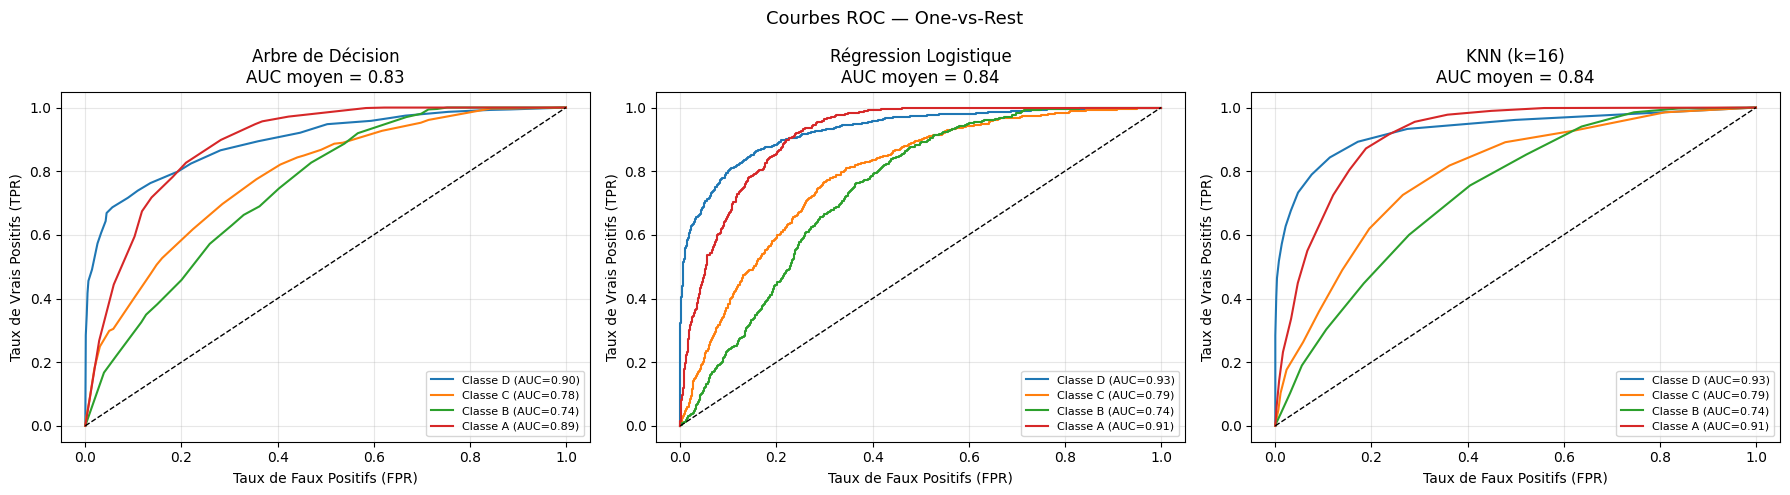

In [116]:
classes = [1, 2, 3, 4]
y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modeles_obj = [
    ('Arbre de Décision', arbre),
    ('Régression Logistique', logreg),
    (f'KNN (k={best_k})', knn)
]

for ax, (nom, modele) in zip(axes, modeles_obj):
    y_score = modele.predict_proba(X_test)
    auc_scores = []

    for i, classe in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc = roc_auc_score(y_test_bin[:, i], y_score[:, i])
        auc_scores.append(auc)
        label = ['D', 'C', 'B', 'A'][i]
        ax.plot(fpr, tpr, label=f'Classe {label} (AUC={auc:.2f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_title(f'{nom}\nAUC moyen = {np.mean(auc_scores):.2f}')
    ax.set_xlabel('Taux de Faux Positifs (FPR)')
    ax.set_ylabel('Taux de Vrais Positifs (TPR)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Courbes ROC — One-vs-Rest', fontsize=13)
plt.tight_layout()
plt.show()

Les courbes ROC montrent de bonnes performances avec des AUC moyens élevés :
- Arbre de Décision     : AUC moyen = 0.83
- Régression Logistique : AUC moyen = 0.84
- KNN (k=16)            : AUC moyen = 0.84

Ces valeurs d'AUC entre 0.80 et 0.90 indiquent une "très bonne" capacité de 
séparation des classes. Le paradoxe entre AUC élevé (~0.84) et accuracy 
modeste (~0.60) s'explique par le fait que l'AUC mesure la qualité du 
classement, tandis que l'accuracy mesure les prédictions exactes. 
Les classes intermédiaires B et C, très proches, font baisser l'accuracy 
sans trop affecter l'AUC.

In [117]:
meilleur = df_resultats['F1-Score (macro)'].idxmax()
meilleur_score = df_resultats['F1-Score (macro)'].max()

print('=' * 55)
print('        CONCLUSION — MEILLEUR MODÈLE')
print('=' * 55)
print(f'  Modèle sélectionné : {meilleur}')
print(f'  F1-Score (macro)   : {meilleur_score:.4f}')
print('=' * 55)
print()
print('Récapitulatif :')
print(df_resultats.to_string())

        CONCLUSION — MEILLEUR MODÈLE
  Modèle sélectionné : KNN (k=16)
  F1-Score (macro)   : 0.6160

Récapitulatif :
                       Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)
Modèle                                                                              
Arbre de Décision        0.5961             0.6076          0.5962            0.5954
Régression Logistique    0.5980             0.5929          0.5980            0.5951
KNN (k=16)               0.6152             0.6259          0.6152            0.6160


In [118]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Accuracy Random Forest :', round(accuracy_score(y_test, y_pred_rf), 4))
print(classification_report(y_test, y_pred_rf,
      target_names=['D(1)', 'C(2)', 'B(3)', 'A(4)']))

Accuracy Random Forest : 0.7141
              precision    recall  f1-score   support

        D(1)       0.88      0.80      0.84       670
        C(2)       0.70      0.66      0.68       670
        B(3)       0.59      0.55      0.57       670
        A(4)       0.69      0.85      0.76       669

    accuracy                           0.71      2679
   macro avg       0.72      0.71      0.71      2679
weighted avg       0.72      0.71      0.71      2679



Random Forest obtient une Accuracy de 0.7141, soit une amélioration 
significative de +11% par rapport aux modèles de base (~0.60).

Par classe :
- D(1) : F1 = 0.84 → très bien prédit (profil physique très distinct)
- A(4) : F1 = 0.76 → bien prédit (profil excellent bien reconnu)
- C(2) : F1 = 0.68 → correct
- B(3) : F1 = 0.57 → classe la plus difficile (profil intermédiaire)

Random Forest combine 200 arbres de décision entraînés sur des 
sous-échantillons aléatoires. Cette diversité réduit le surapprentissage 
et améliore considérablement la généralisation par rapport à un seul arbre.

In [119]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print('Accuracy Gradient Boosting :', round(accuracy_score(y_test, y_pred_gb), 4))
print(classification_report(y_test, y_pred_gb,
      target_names=['D(1)', 'C(2)', 'B(3)', 'A(4)']))

Accuracy Gradient Boosting : 0.7324
              precision    recall  f1-score   support

        D(1)       0.90      0.82      0.86       670
        C(2)       0.71      0.65      0.68       670
        B(3)       0.61      0.61      0.61       670
        A(4)       0.73      0.84      0.78       669

    accuracy                           0.73      2679
   macro avg       0.74      0.73      0.73      2679
weighted avg       0.74      0.73      0.73      2679



Gradient Boosting obtient la meilleure Accuracy globale : 0.7324, 
soit +13% par rapport aux modèles de base.

Il construit les arbres séquentiellement : chaque nouvel arbre corrige 
les erreurs du précédent. C'est pourquoi il surpasse Random Forest qui 
construit les arbres indépendamment.

                       Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)
Modèle                                                                              
Arbre de Décision        0.5961             0.6076          0.5962            0.5954
Régression Logistique    0.5980             0.5929          0.5980            0.5951
KNN (k=16)               0.6152             0.6259          0.6152            0.6160
Random Forest            0.7141             0.7169          0.7141            0.7126
Gradient Boosting        0.7324             0.7361          0.7324            0.7326


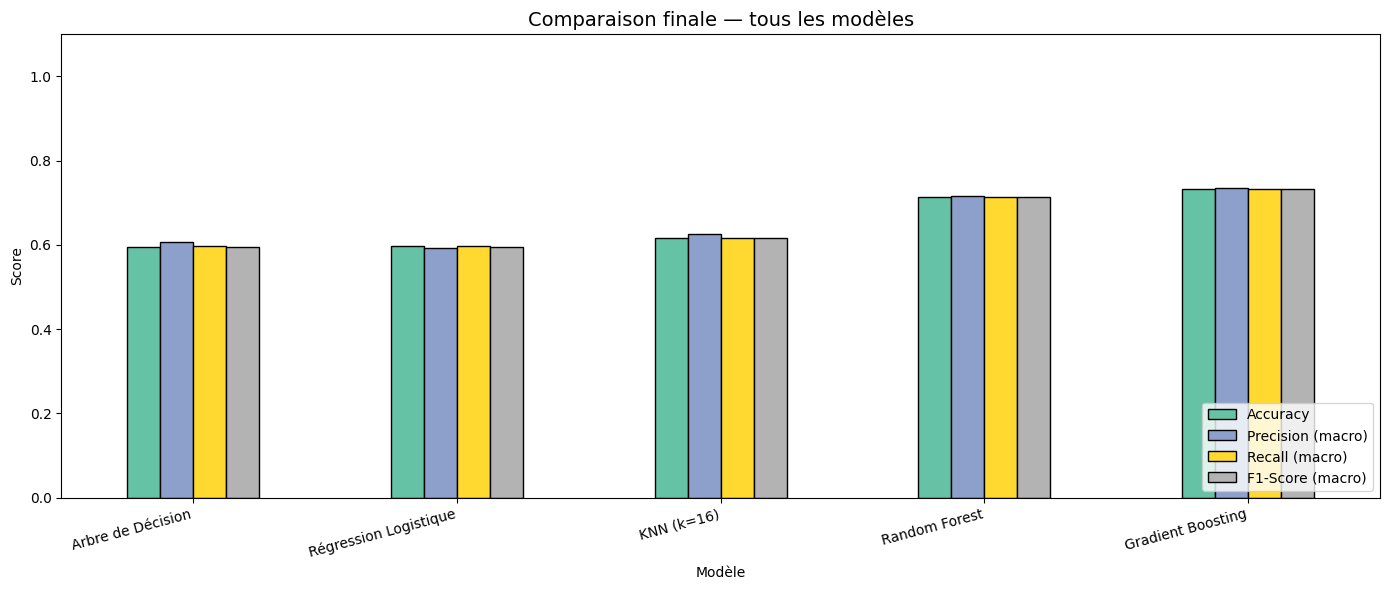


✅ Meilleur modèle : Gradient Boosting
   F1-Score : 0.7326


In [120]:
# Ajouter les nouveaux modèles au tableau comparatif
nouveaux = [
    ('Random Forest', y_pred_rf),
    ('Gradient Boosting', y_pred_gb)
]

for nom, y_pred in nouveaux:
    resultats.append({
        'Modèle': nom,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision (macro)': round(precision_score(y_test, y_pred, average='macro'), 4),
        'Recall (macro)': round(recall_score(y_test, y_pred, average='macro'), 4),
        'F1-Score (macro)': round(f1_score(y_test, y_pred, average='macro'), 4)
    })

df_resultats_final = pd.DataFrame(resultats).set_index('Modèle')
print(df_resultats_final.to_string())

# Graphique
df_resultats_final.plot(kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='black')
plt.title('Comparaison finale — tous les modèles', fontsize=14)
plt.xlabel('Modèle')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Meilleur modèle final
meilleur_final = df_resultats_final['F1-Score (macro)'].idxmax()
print(f'\n✅ Meilleur modèle : {meilleur_final}')
print(f'   F1-Score : {df_resultats_final["F1-Score (macro)"].max():.4f}')

Classement final des 5 modèles par F1-Score :

1. Gradient Boosting  : F1 = 0.7326  ← MEILLEUR
2. Random Forest      : F1 = 0.7126
3. KNN (k=16)         : F1 = 0.6160
4. Arbre de Décision  : F1 = 0.5954
5. Régression Log.    : F1 = 0.5951

Observations importantes :
- Les modèles ensemblistes (Random Forest, Gradient Boosting) surpassent 
  largement les modèles simples (+11 à +13% d'accuracy).
- Les 3 modèles de base ont des performances quasi identiques (~0.60), 
  ce qui confirme que la limite vient de la complexité du problème 
  (classes B et C difficiles à séparer) et non du choix du modèle.
- Le Gradient Boosting est le modèle recommandé pour prédire la classe 
  de performance physique sur ce dataset.

Récapitulatif des gains par rapport à un modèle aléatoire (25%) :
- Modèles simples   : 0.60 → 2.4× mieux que le hasard
- Random Forest     : 0.71 → 2.8× mieux que le hasard  
- Gradient Boosting : 0.73 → 2.9× mieux que le hasard

Cette étude a appliqué 5 algorithmes de Machine Learning sur le dataset 
bodyPerformance pour prédire la classe de performance physique (A, B, C, D).

APPRENTISSAGE NON SUPERVISÉ :
- K-Means et CAH ont tous deux identifié naturellement 4 groupes cohérents 
  avec les classes réelles, validant la structure du dataset.

APPRENTISSAGE SUPERVISÉ :
- Les modèles simples (Arbre, Régression Logistique, KNN) atteignent ~0.60.
- Les modèles ensemblistes améliorent significativement les résultats.
- Le Gradient Boosting est le meilleur modèle avec F1 = 0.7326.

La difficulté principale vient des classes intermédiaires B et C, 
physiquement très proches, qui génèrent la majorité des erreurs de 
classification dans tous les modèles.

Le modèle Gradient Boosting est recommandé pour déployer un système 
de prédiction automatique de la classe de performance physique 
d'un individu à partir de ses mesures corporelles.